In [1]:
import numpy as np
from scipy.special import softmax
import pandas as pd
import seaborn as sns
import pylab as pl
from scipy.optimize import minimize, differential_evolution
import belief_mix_model as bmm
import belief_mix_model_with_spatial_mix_normalized as bmm_spat
from scipy.spatial.distance import cdist,pdist,euclidean
from collections import Counter
import scipy as sp
from matplotlib.patches import Ellipse

In [2]:
data_dir = "../Lucas_Cecile/"
fig_dir = "./figures/brinkman_board/"

In [58]:
processed_data = pd.read_csv(data_dir+"extracted_trajs.csv")
random_agent = pd.read_csv(data_dir+"random_agent.csv")

all_data = pd.concat([processed_data, random_agent])

In [4]:
ps = "with_spatial_mixture_bias_normalized"

In [60]:
fittings = pd.read_csv(data_dir+"fittings_"+ps+".csv")
recovery_df = pd.read_csv(data_dir+"recovery_df_spatial_mix_normalized"+".csv")

In [6]:
phase_order = ['Habituation', 'Test','Post-test']
cmap1 = 'Accent'
cmap2 = 'tab10'

In [50]:
def plot_boxplots_with_points(x_var,y_var,col_var,hue_var,order,palette,data,col_wrap,dodge=False,sharey=True):
   
    g1 = sns.catplot(x=x_var,y=y_var,col=col_var,data=data,kind='box',hue=hue_var,col_wrap=col_wrap,palette=palette,order=order,fill=False,dodge=dodge,sharey=sharey)
    for ax in g1.axes:
        for x in ax.get_xticklabels():
            x.set_rotation(45)
            x.set_ha('right')
        ax.set_xlabel("")
        tit = ax.get_title().split(' = ')[1]
        sub = data.loc[data[col_var]==tit].copy()
        sns.stripplot(ax=ax,data=sub,x=x_var,y=y_var,hue=hue_var,palette=palette,order=order,dodge=dodge,legend=False,s=6)
        ax.set_xlabel("")
    g1.figure.subplots_adjust(bottom=0.2)

    return g1


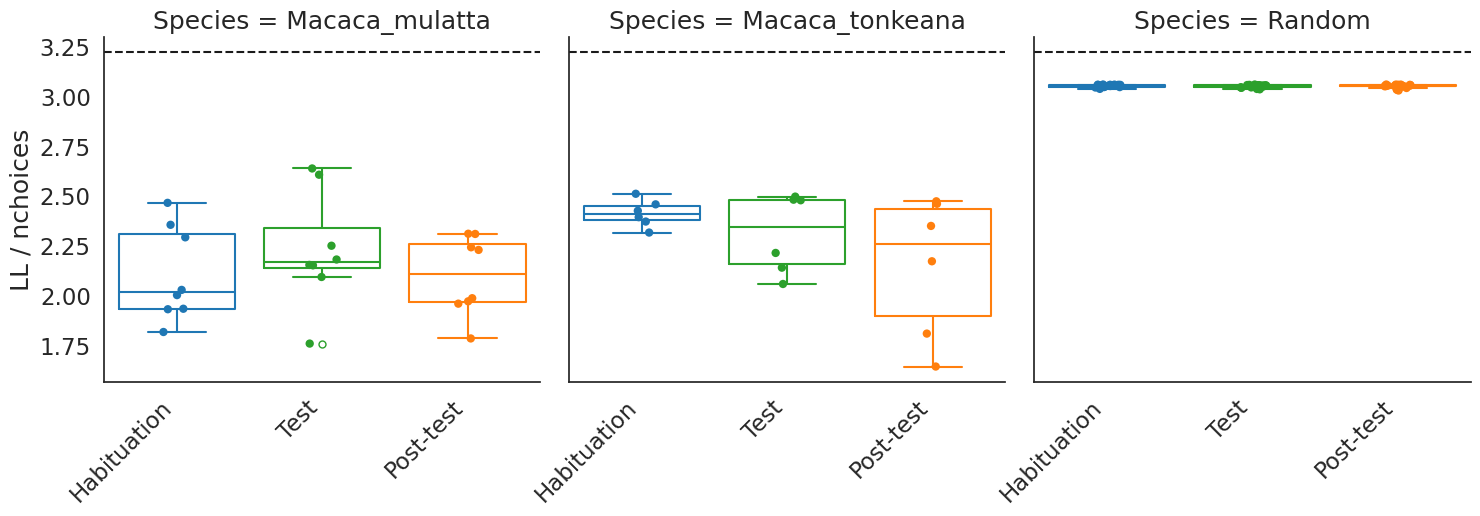

In [51]:
# g1 = sns.catplot(x="Phase",y="LL / nchoices",hue='Species',kind='box',data=fittings)
g1 = plot_boxplots_with_points("Phase","LL / nchoices","Species","Phase",phase_order,cmap2,fittings,3)

for ax in g1.axes:
    xlims = ax.get_xlim()
    ax.hlines(y=3.22,xmin=xlims[0],xmax=xlims[1],ls='dashed',color='k',lw=1.5)
    ax.set_xlim(xlims[0],xlims[1])
g1.savefig(fig_dir+"LLs_with_respect_to_chance_level.png")

In [52]:
compare_trajs = pd.DataFrame()
compare_stats = pd.DataFrame()
compare_dist_trajs = pd.DataFrame()
compare_visit_map = pd.DataFrame()

for grp in fittings.groupby(['Subject','Phase','Species']):
    wRS, wCS, wSS,  wK, wR, wM, decay,beta = grp[1]['W(row_scan)'].values[0], grp[1]['W(column_scan)'].values[0], grp[1]['W(spiral_scan)'].values[0],grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0],grp[1]['beta'].values[0]
    sim_trajs = []
    act_data = all_data.loc[(all_data['Subject']==grp[0][0])&(all_data['Phase']==grp[0][1])&(all_data['Species']==grp[0][2])].copy()
    act_trajs = [ [[x,y]  for x,y in zip(tr[1].Rows,tr[1].Cols)] for tr in act_data.groupby('Session') ]
    
    Nsim = len(act_trajs)
    stats_act = dict({'revisit_rate':[],'traj_num':[],'jump_length':[],'first_revisit':[],'total_dist':[]})
    stats_sim = dict({'revisit_rate':[],'traj_num':[],'jump_length':[],'first_revisit':[],'total_dist':[]})
    
    dist_between_trajs = []
    corr_between_trajs = []
    trials = []
    for i,traj in enumerate(act_trajs):

        start = traj[0]
        sim, _, _, _ = bmm_spat.simulate_case(

            start_loc=start,
            T=len(traj)-1,
            sigma=1.0,
            decay=decay,
            wK=wK,
            wR=wR,
            wM=wM,
            beta=beta,
            wRS = wRS,
            wCS = wCS,
            wSS = wSS
        )                        

        sim_trajs.append(sim)  
        trials.append([i]*len(traj))
        
        revis_act, first_rev_act = bmm.revisit_rate(traj)
        revis_sim,first_rev_sim = bmm.revisit_rate(sim)
        
        mean_jump_act, var_jump_act, tot_jump_act = bmm.jump_lengths(traj)
        mean_jump_sim, var_jump_sim, tot_jump_sim = bmm.jump_lengths(sim)
        
        tot_dist_act = bmm.calc_total_distance_covered(traj)
        tot_dist_sim = bmm.calc_total_distance_covered(sim)
        
        stats_act['revisit_rate'].append(revis_act)
        stats_act['jump_length'].append(mean_jump_act)
        stats_act['first_revisit'].append(first_rev_act)
        stats_act['total_dist'].append(tot_dist_act)
        stats_act['traj_num'].append(i)
        
        stats_sim['revisit_rate'].append(revis_sim)
        stats_sim['jump_length'].append(mean_jump_sim)
        stats_sim['first_revisit'].append(first_rev_sim)
        stats_sim['total_dist'].append(tot_dist_sim)
        stats_sim['traj_num'].append(i)
        
        dist,corr = bmm.calc_dist_bw_traj(traj,sim)
        dist_between_trajs.append(dist)

        
    
    Vobs = sum(bmm.visit_map(t) for t in act_trajs)
    Vsim = sum(bmm.visit_map(t) for t in sim_trajs)
    
    Vobs_df = pd.DataFrame(Vobs,columns=np.arange(1,6),index=np.arange(1,6))
    Vobs_df['type'] = 'data'
    
    Vsim_df = pd.DataFrame(Vsim,columns=np.arange(1,6),index=np.arange(1,6))
    Vsim_df['type'] = 'model'
    
    Vmap = pd.concat([Vobs_df,Vsim_df])
    Vmap['Subject'] = grp[0][0]
    Vmap['Phase'] = grp[0][1]
    Vmap['Species'] = grp[0][2]
    
    compare_visit_map = pd.concat([compare_visit_map,Vmap])
    
    
    stats_act_df = pd.DataFrame(stats_act)
    stats_act_df['type'] = 'data'
    
    stats_sim_df = pd.DataFrame(stats_sim)
    stats_sim_df['type'] = 'model'
    to_add = pd.concat([stats_act_df,stats_sim_df])
    to_add['Subject'] = grp[0][0]
    to_add['Phase'] = grp[0][1]
    to_add['Species'] = grp[0][2]
    
    compare_stats = pd.concat([compare_stats,to_add])
    
    temp_df = pd.DataFrame()
    temp_df['dist_traj(model,data)'] = dist_between_trajs

    temp_df['Subject'] = grp[0][0]
    temp_df['Phase'] = grp[0][1]
    temp_df['Species'] = grp[0][2]
    
    compare_dist_trajs = pd.concat([compare_dist_trajs,temp_df])
    

    
        
        
    
    temp = pd.DataFrame()
    temp['Rows_model'] = np.array(sim_trajs)[:,:,0].flatten()
    temp['Cols_model'] = np.array(sim_trajs)[:,:,1].flatten()
   
    temp['Rows_data'] = np.array(act_trajs)[:,:,0].flatten()
    temp['Cols_data'] = np.array(act_trajs)[:,:,1].flatten()
    temp['Trials'] = np.hstack(trials)
    temp['Subject'] = grp[0][0]
    temp['Phase'] = grp[0][1]
    temp['Species'] = grp[0][2]
    #temp['spatial_bias'] = grp[1]['spatial_bias'].values[0]
    compare_trajs = pd.concat([compare_trajs,temp])
        
        
compare_stats.to_csv(data_dir+"compare_stats"+ps+".csv")
compare_trajs.to_csv(data_dir+"compare_trajs"+ps+".csv")
compare_dist_trajs.to_csv(data_dir+"compare_dist_between_trajs_"+ps+".csv")

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

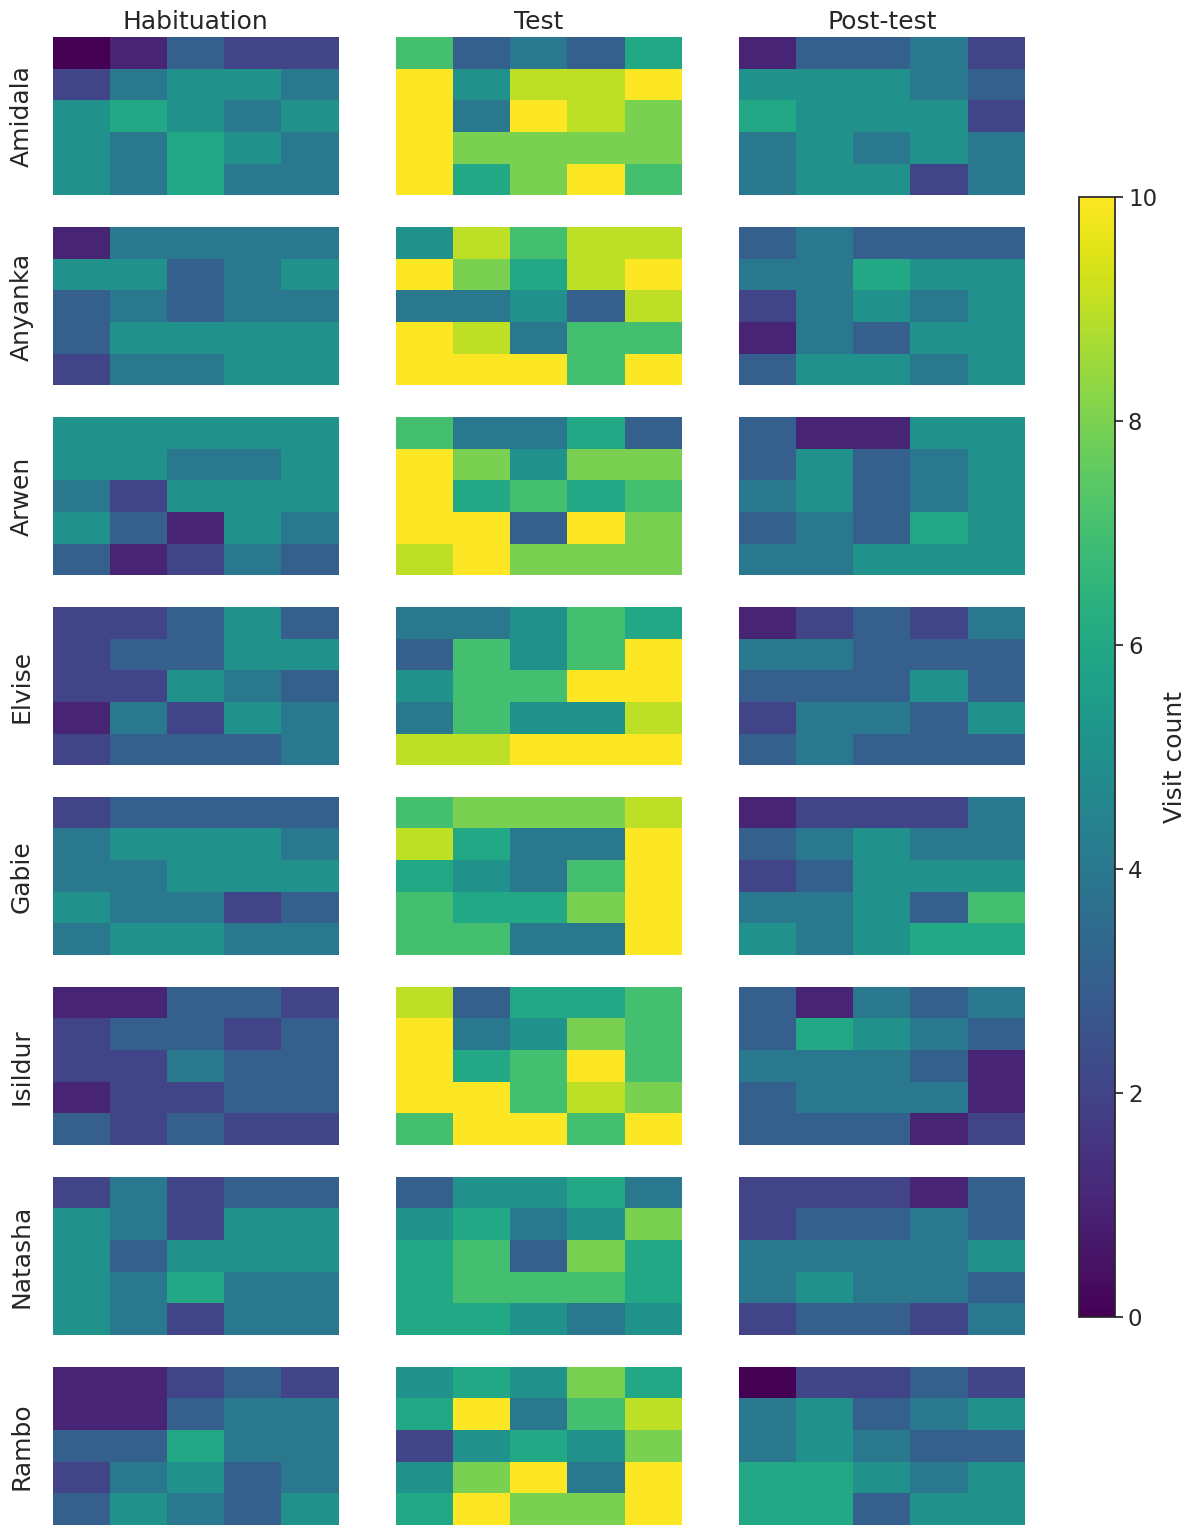

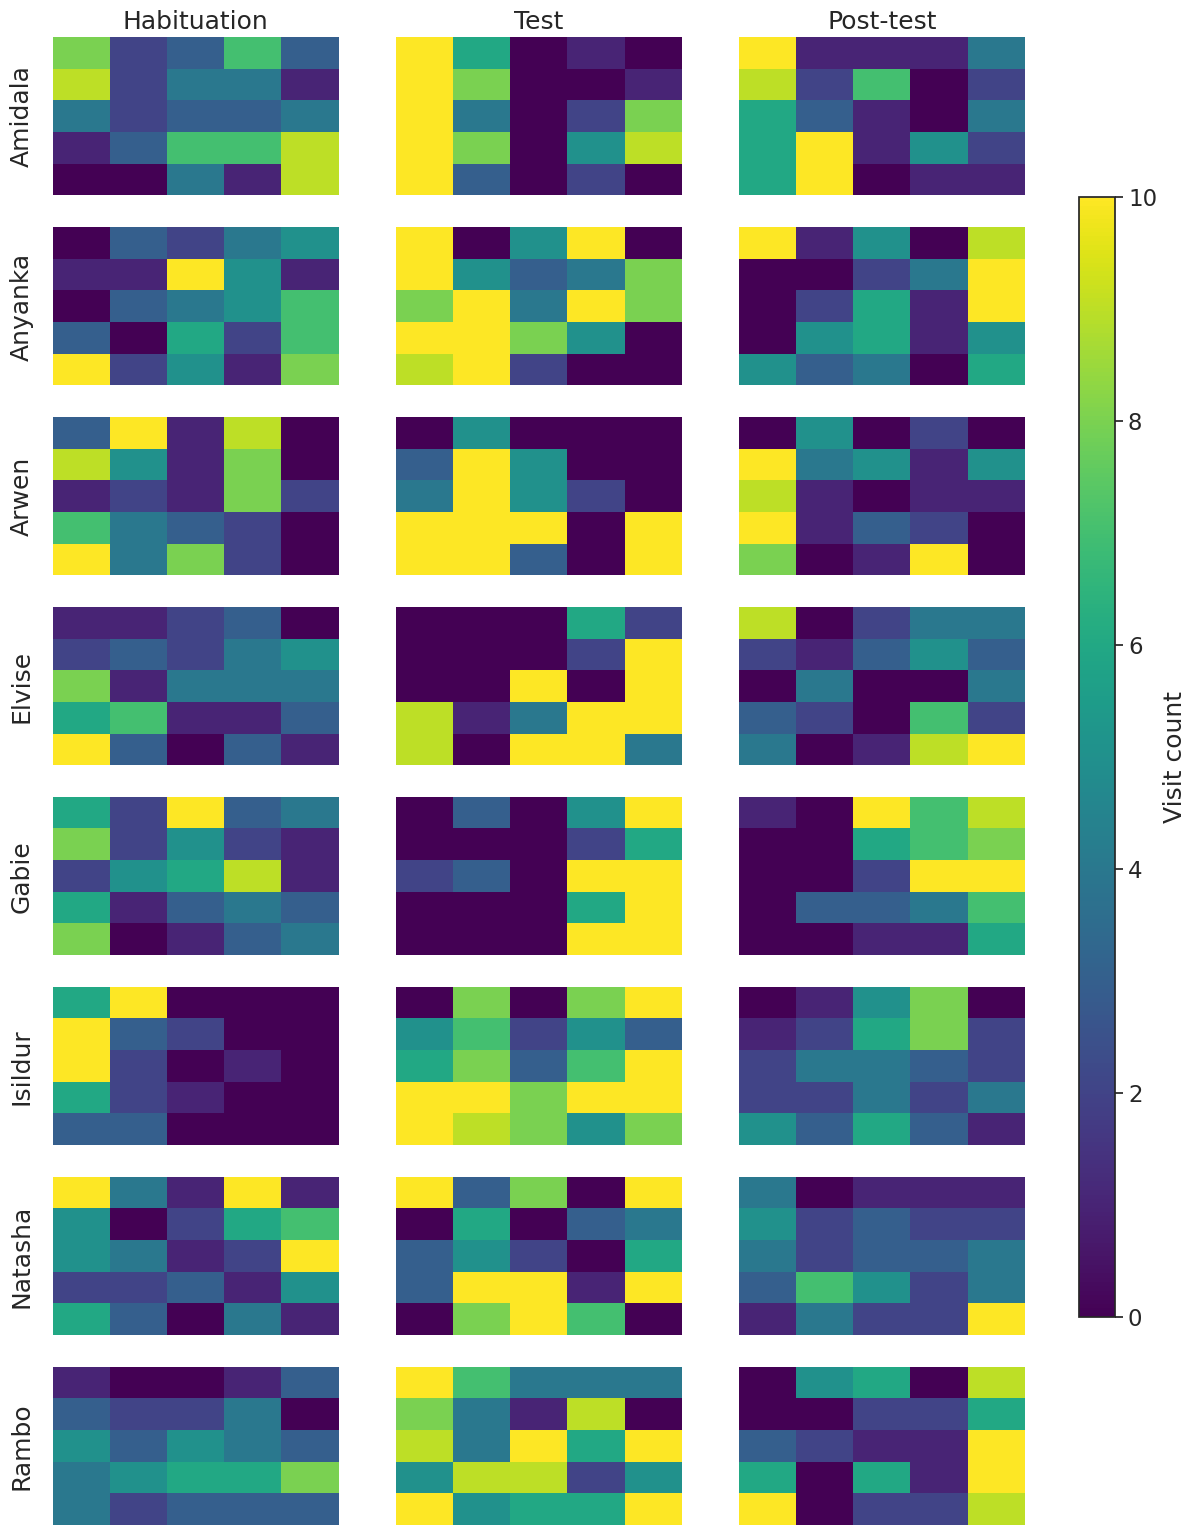

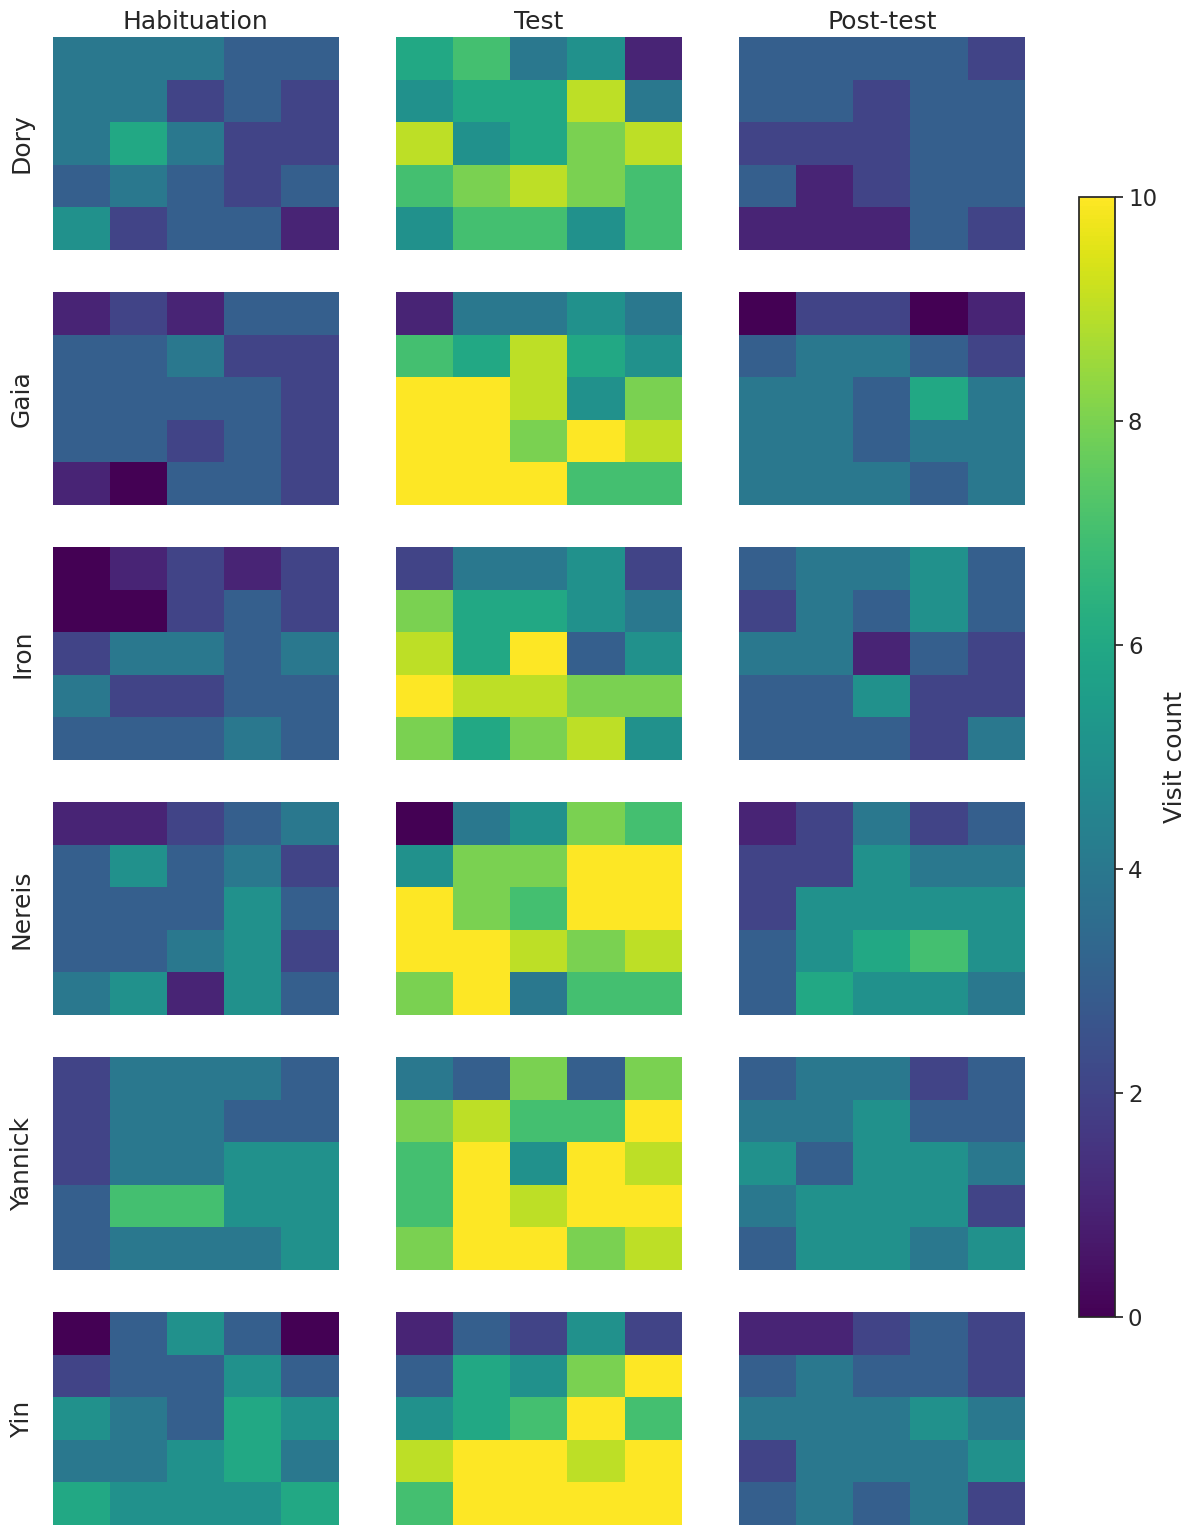

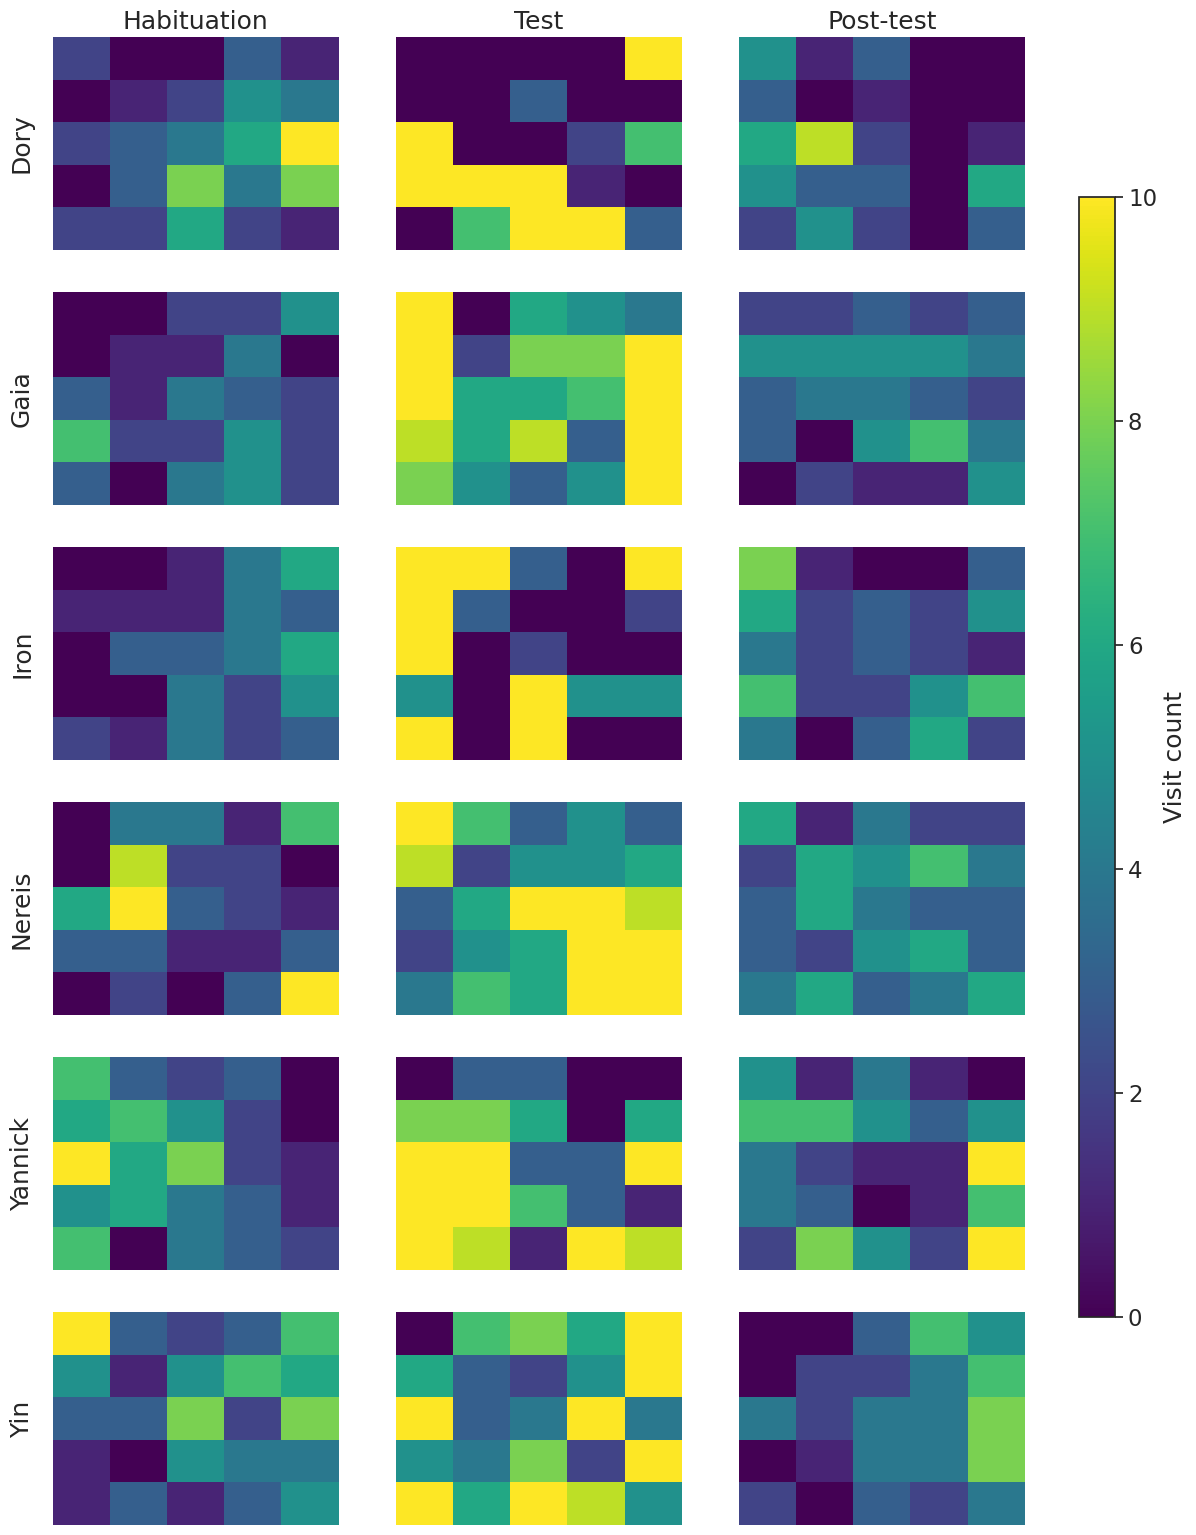

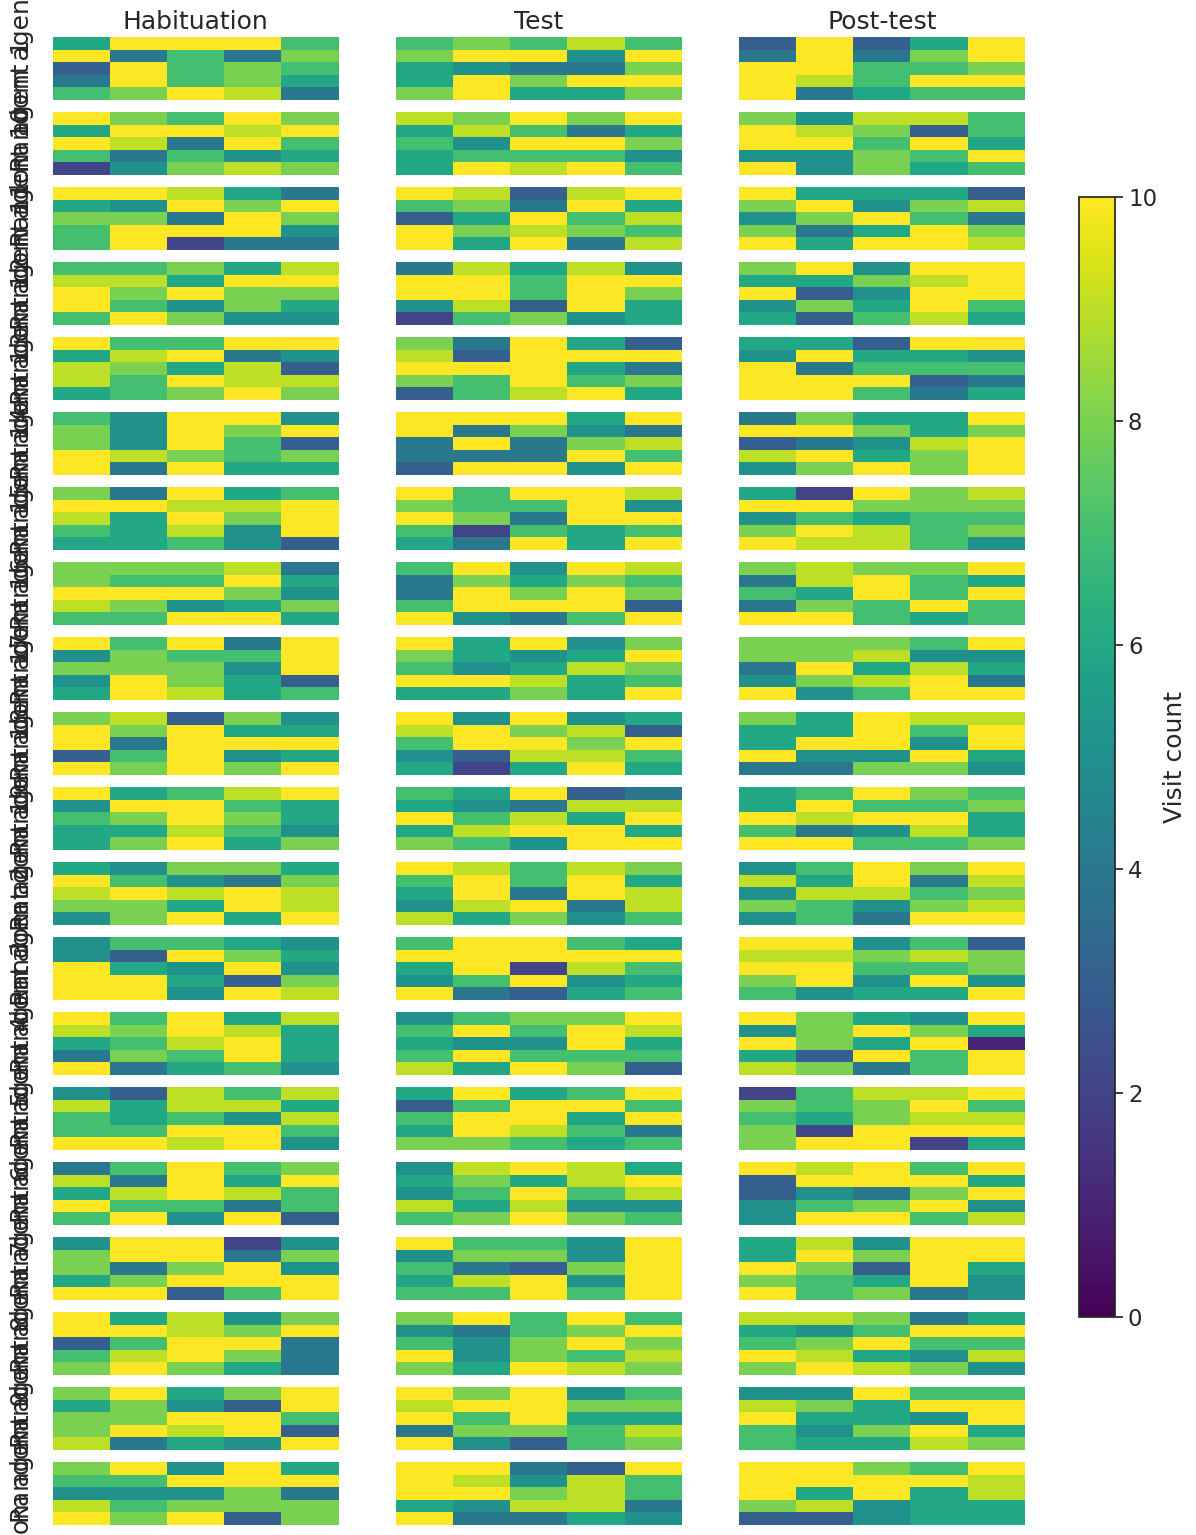

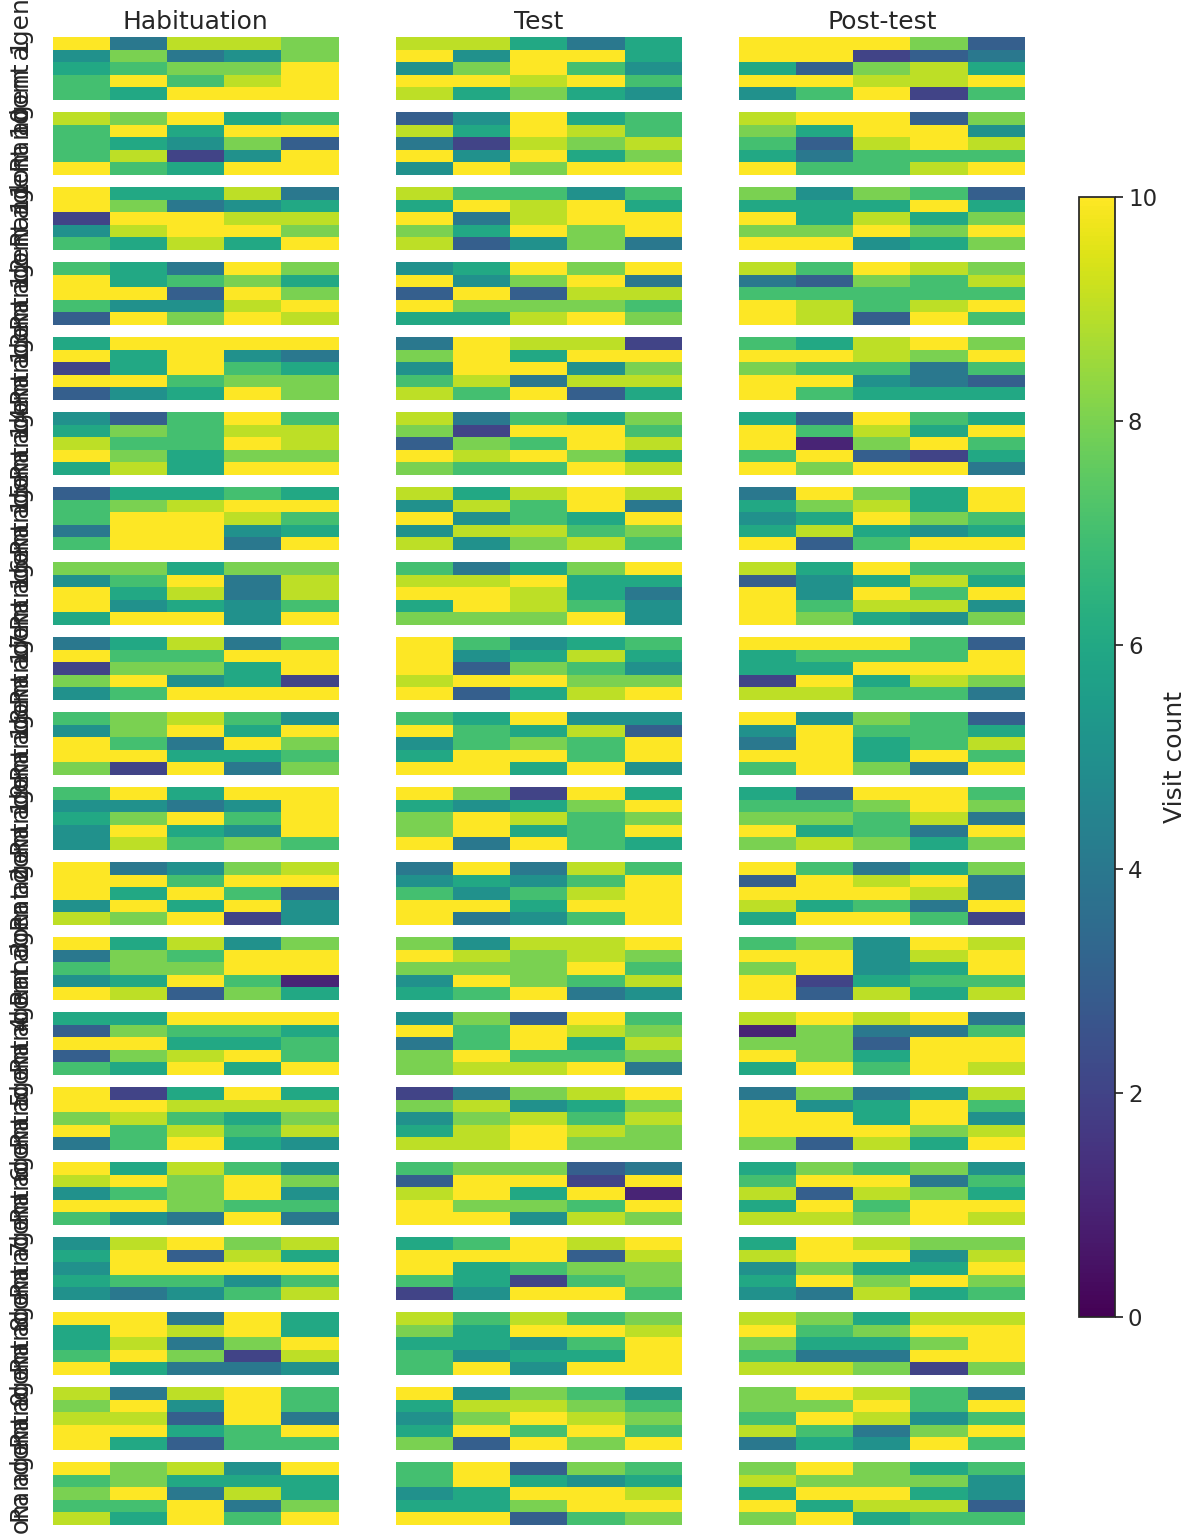

In [29]:
sns.set(style='white',font_scale=1.5)
for grp in compare_visit_map.groupby(['Species','type']):
    num_sub = len(grp[1]['Subject'].unique())
    rows,cols = num_sub, 3
    fig,ax = pl.subplots(rows,cols,figsize=(12,16))
    
    for i,sub in enumerate(grp[1].groupby('Subject')):
        for j,ph in enumerate(phase_order):
            sl = sub[1].loc[sub[1]['Phase']==ph].copy()
            hm = sns.heatmap(sl[sl.columns[:5]],annot=False, cbar=False, ax=ax[i][j], vmin=0,vmax=10,cmap='viridis')
    
            if i == 0:
                ax[i][j].set_title(phase_order[j])
            ax[i][j].set_xticklabels([])
            ax[i][j].set_yticklabels([])
        ax[i][0].set_ylabel(sub[0])
        mappable = hm.collections[0]

    cbar_ax = fig.add_axes([0.915, 0.15, 0.03, 0.7])

    fig.colorbar(
        mappable,
        cax=cbar_ax,
        label="Visit count"
    )        
#     pl.tight_layout()
    fig.subplots_adjust(right=0.87,top=0.95,left=0.06,bottom=0.02)
    fig.savefig(fig_dir+"Visit_heat_map_"+grp[0][0]+"_"+grp[0][1]+ps+".png")


In [31]:
stats_melt = compare_stats.melt(id_vars=['Subject','Species','Phase','type','traj_num'])

<Figure size 640x480 with 0 Axes>

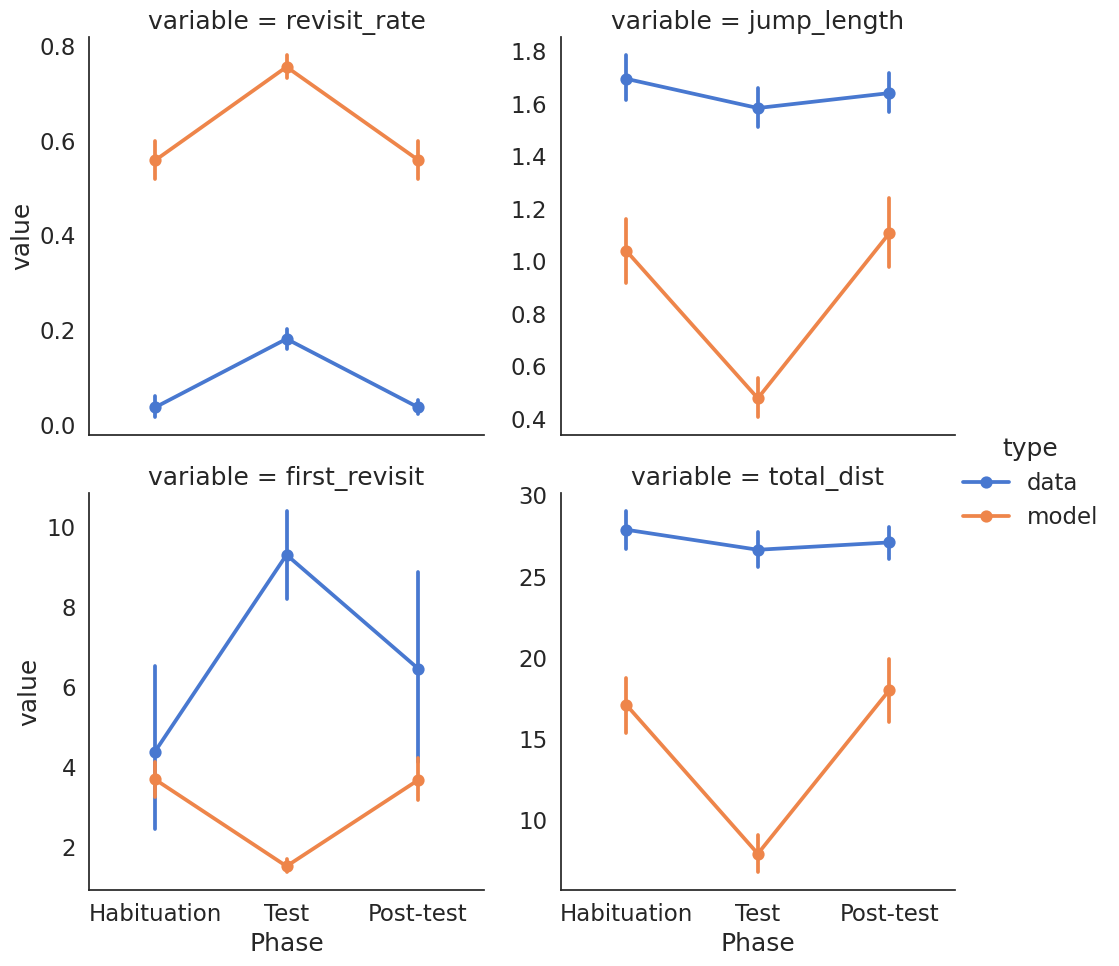

<Figure size 640x480 with 0 Axes>

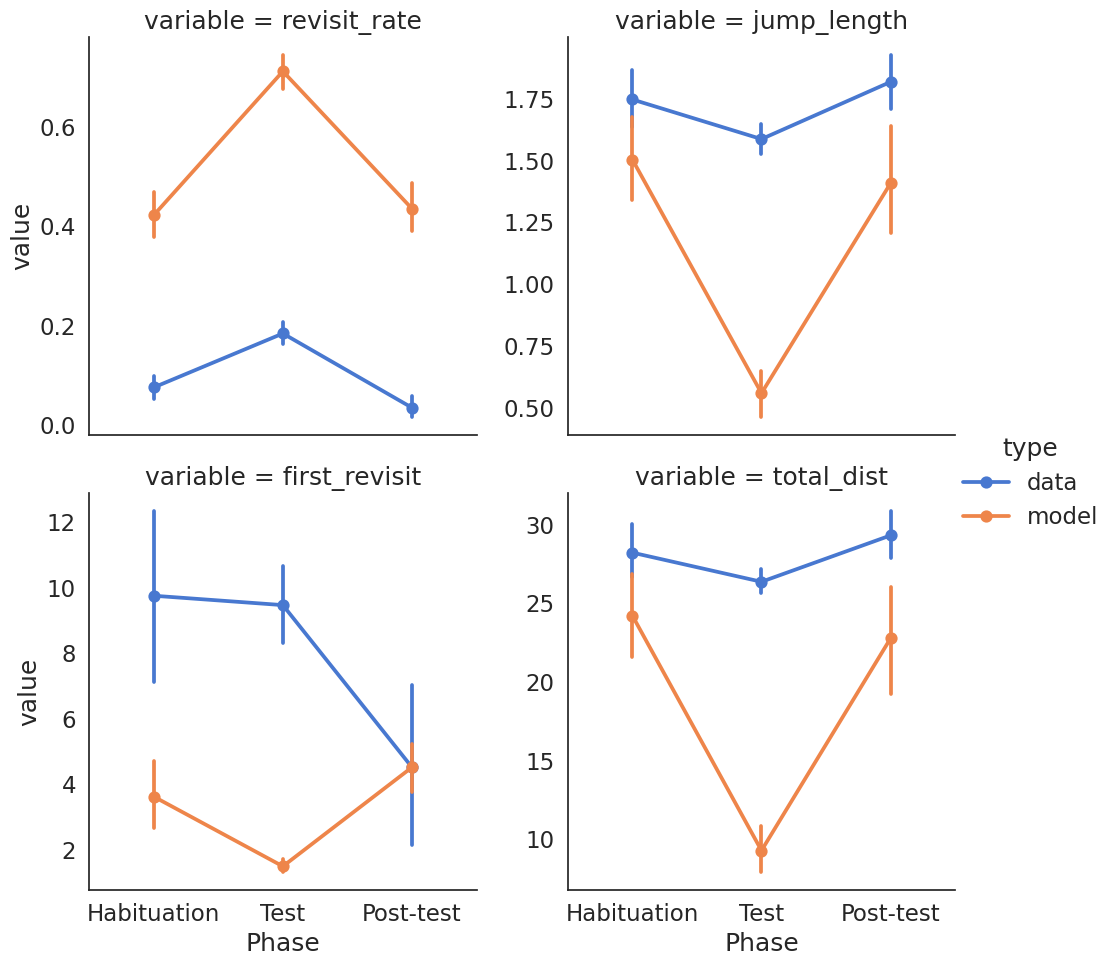

<Figure size 640x480 with 0 Axes>

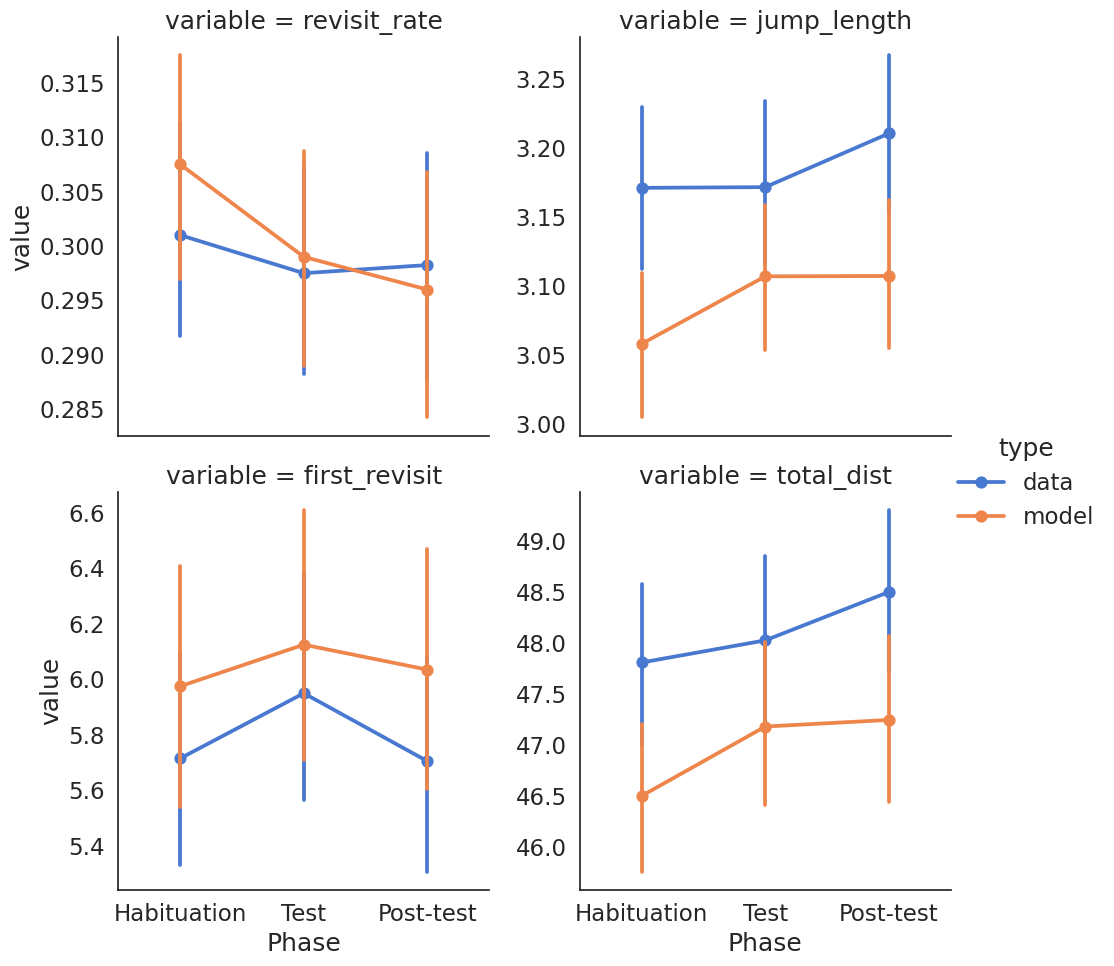

In [32]:
for grp in stats_melt.groupby('Species'):
    pl.figure()
    g1 = sns.catplot(x="Phase",y='value',hue='type',kind='point',col='variable',col_wrap=2,data=grp[1],sharey=False,palette='muted',order=phase_order)
    g1.savefig(fig_dir+"stats_compare_data_model_"+grp[0]+ps+".png")

In [44]:
to_plot = fittings.melt(id_vars=['Subject','Species','Phase','LL'])

to_plot = to_plot.loc[~to_plot['variable'].str.contains('Unnamed')]


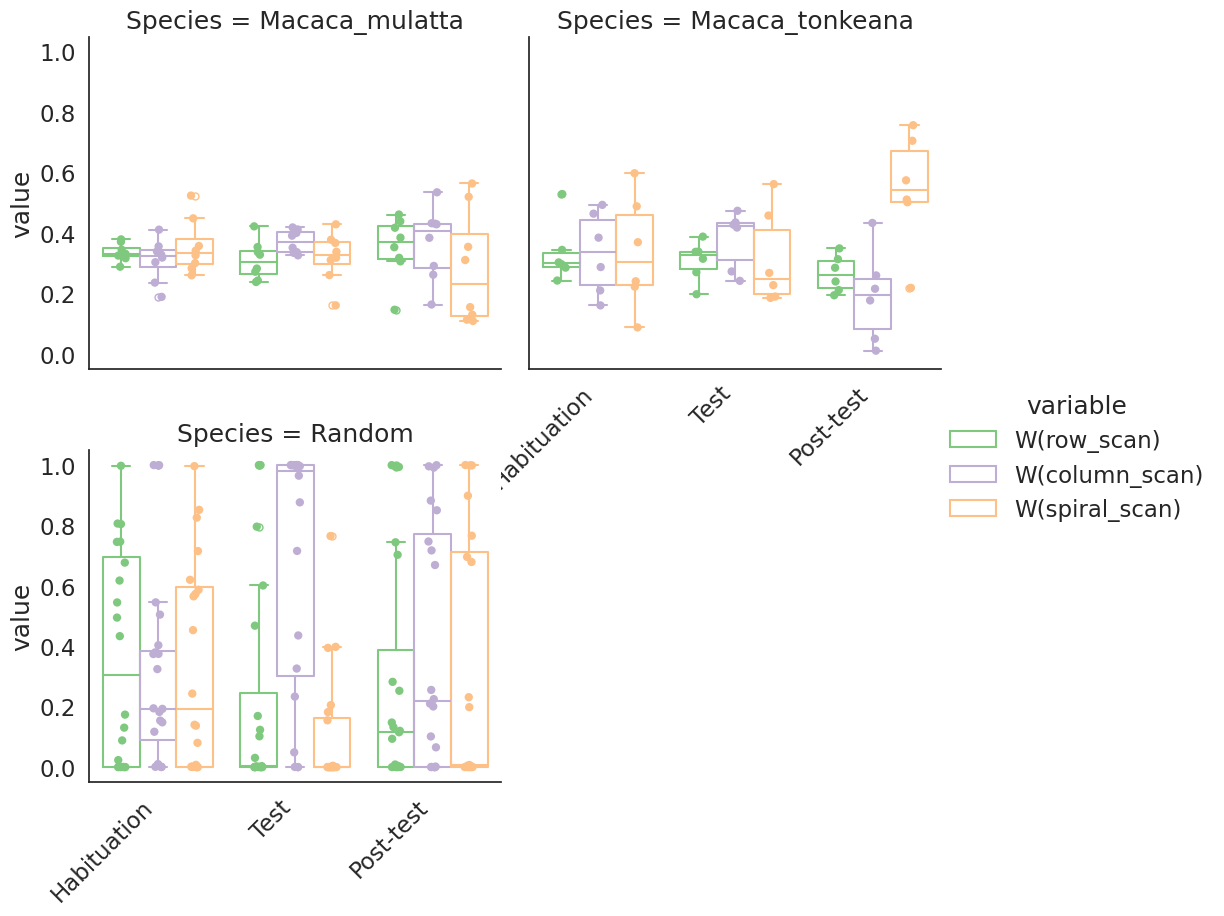

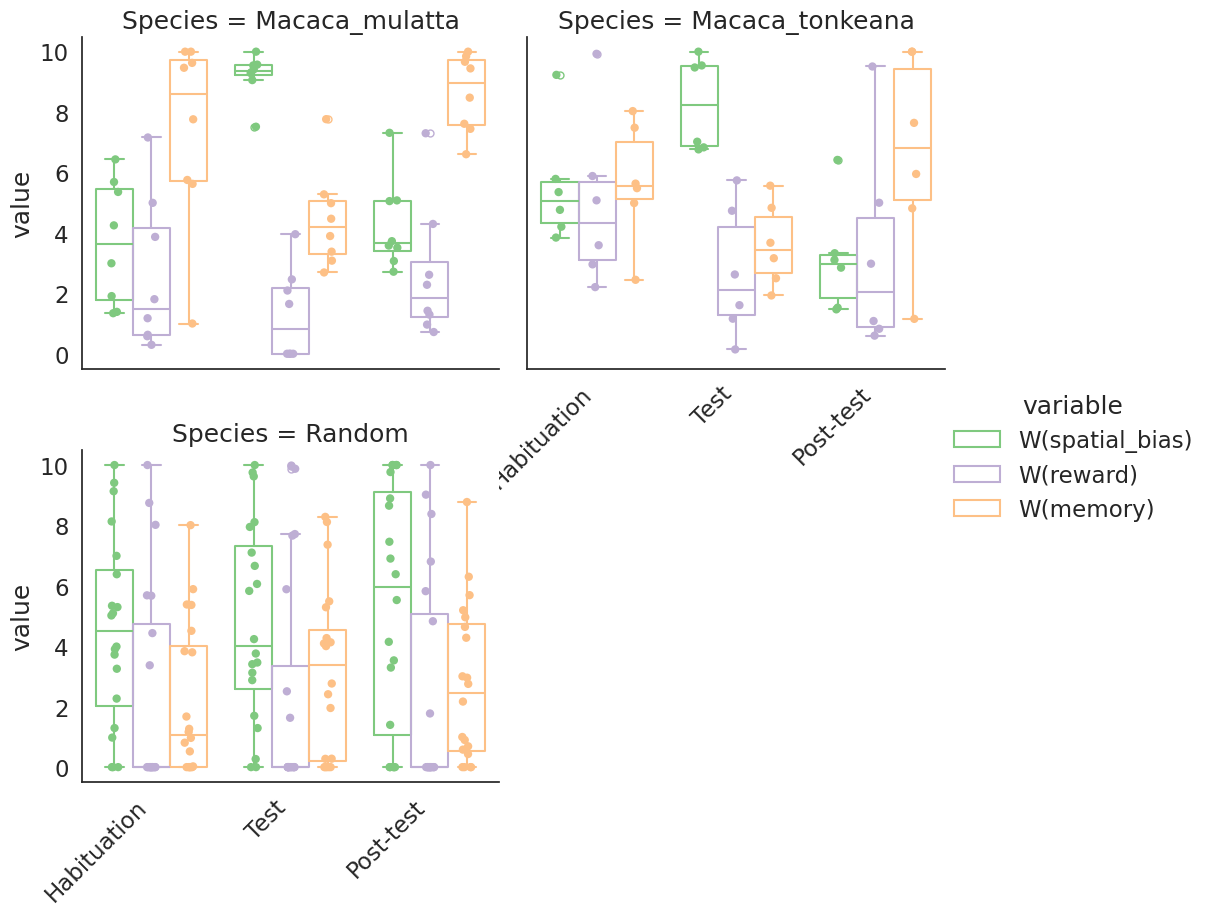

In [53]:
weights_spatial_df = to_plot.loc[to_plot['variable'].str.contains('_scan')].copy()
weights_other_df = to_plot.loc[(to_plot['variable'].str.contains('W')&~(to_plot['variable'].str.contains('_scan')))].copy()

g1_sp_wt = plot_boxplots_with_points("Phase","value","Species",'variable',phase_order,cmap1,weights_spatial_df,2,True,True)
g1_sp_wt.savefig(fig_dir+"comparison_weights_with_points_spatial_mix_"+ps+".png")    


g1_oth_wt = plot_boxplots_with_points("Phase","value",'Species','variable',phase_order,cmap1,weights_other_df,2,True,True)
g1_oth_wt.savefig(fig_dir+"comparison_weights_with_points_other_"+ps+".png")    

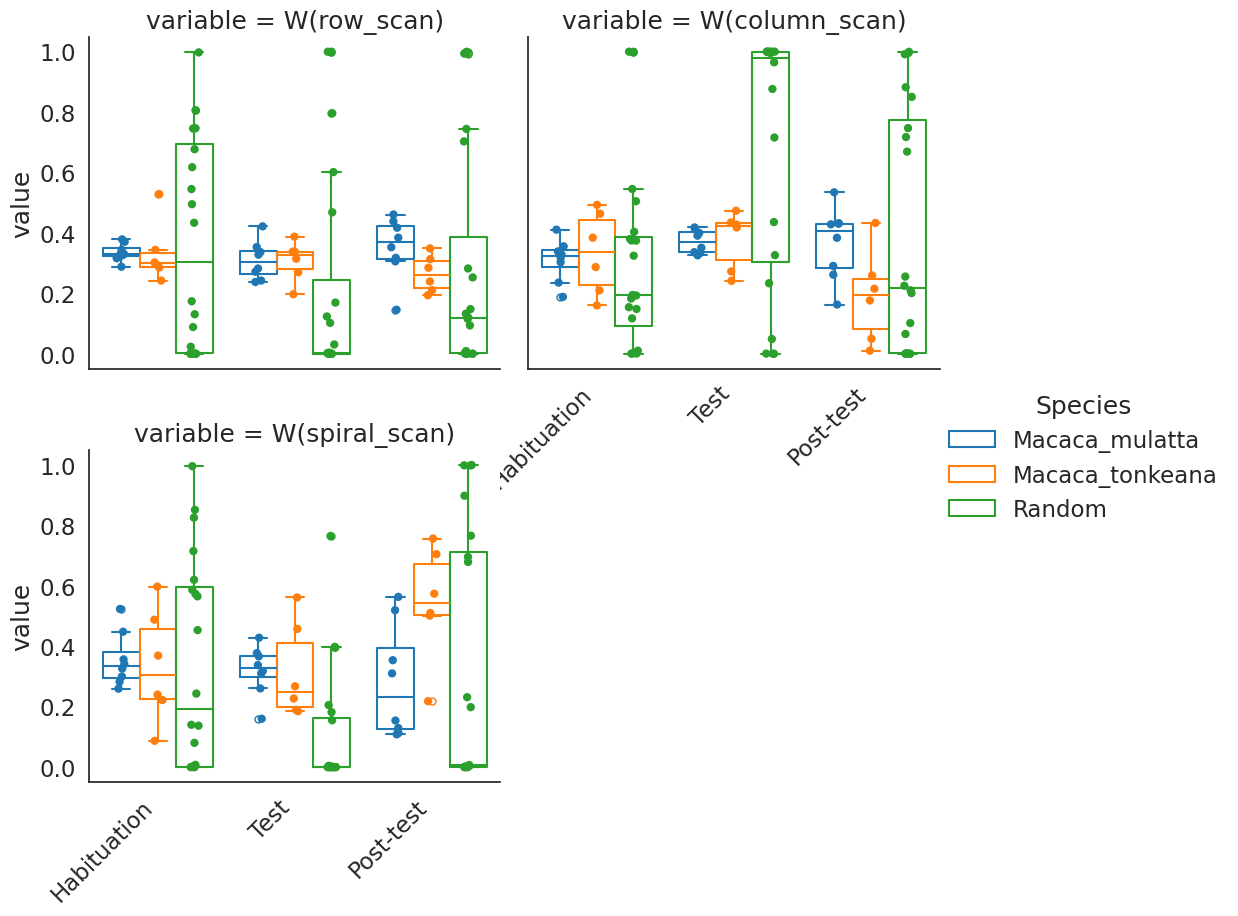

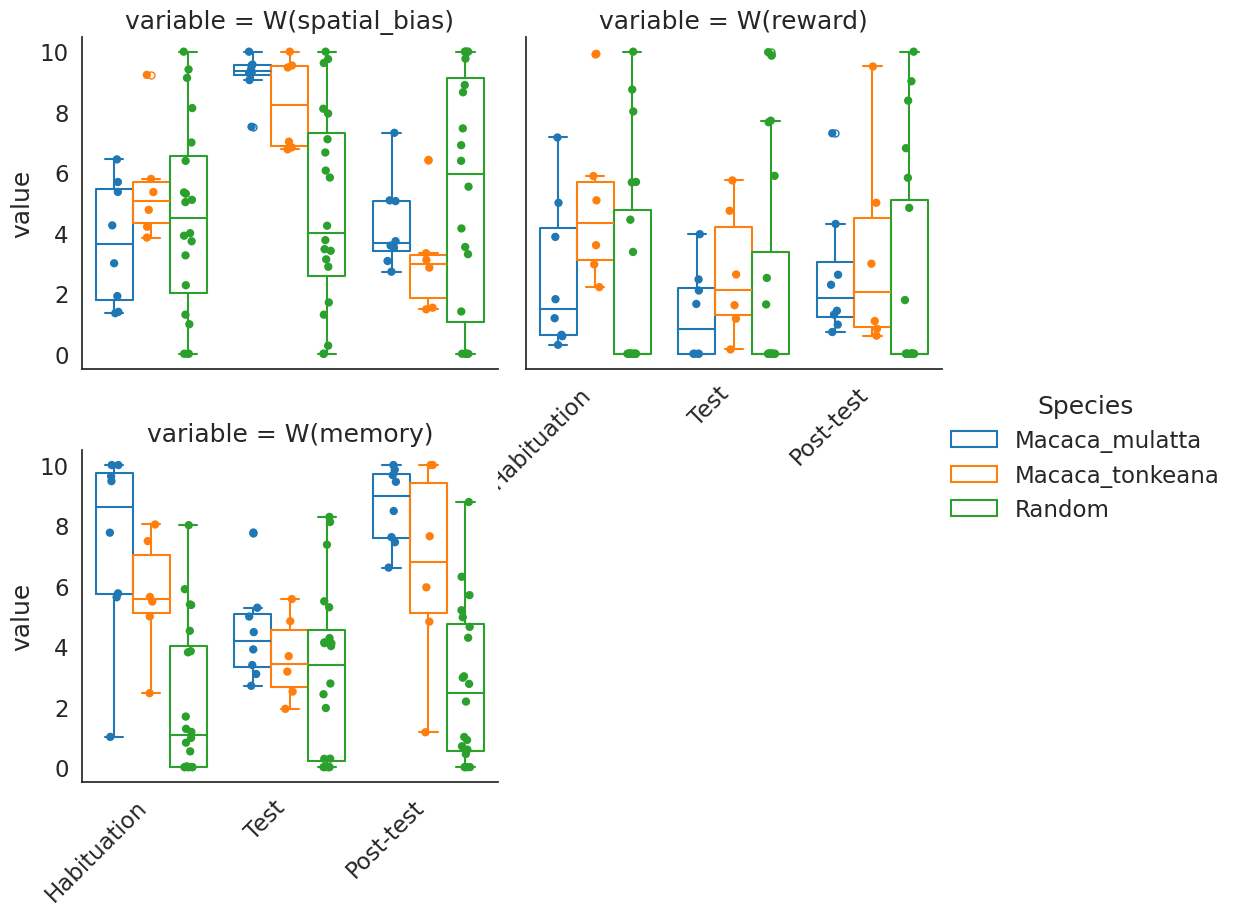

In [54]:
g1_sp_wt = plot_boxplots_with_points("Phase","value",'variable','Species',phase_order,cmap2,weights_spatial_df,2,True,True)

g1_sp_wt.savefig(fig_dir+"comparison_weights_with_points1_spatial_mix_"+ps+".png")    

g1_oth_wt = plot_boxplots_with_points("Phase","value",'variable','Species',phase_order,cmap2,weights_other_df,2,True,True)
g1_oth_wt.savefig(fig_dir+"comparison_weights_with_points1_other_"+ps+".png")      

Macaca_mulatta
Macaca_tonkeana
Random
Macaca_mulatta
Macaca_tonkeana
Random


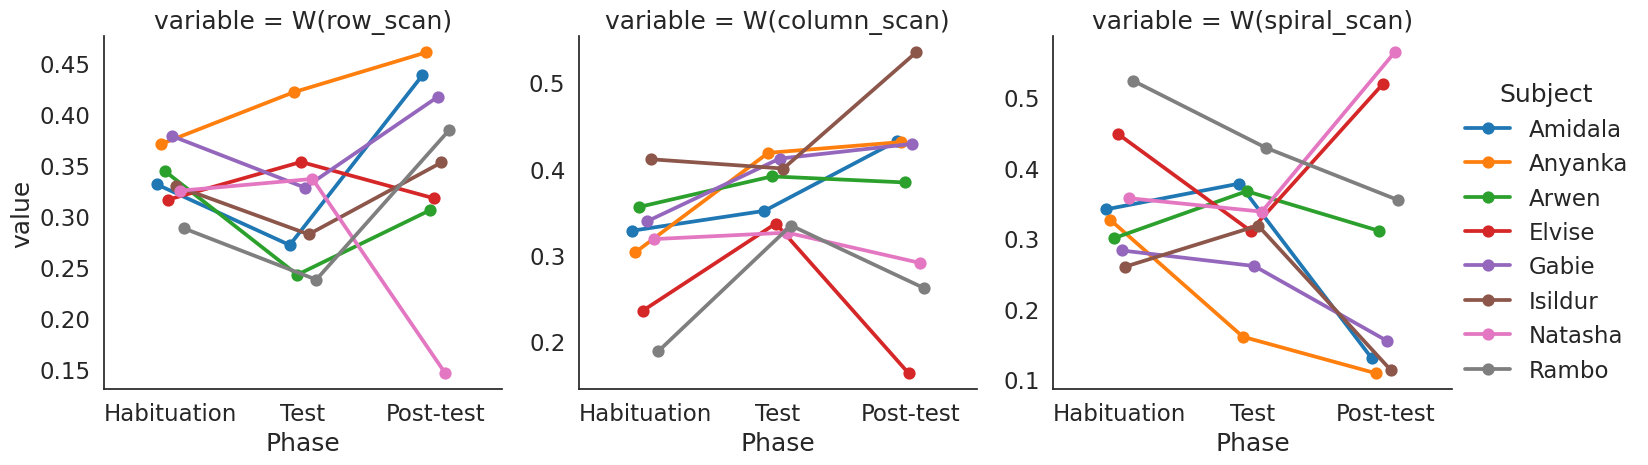

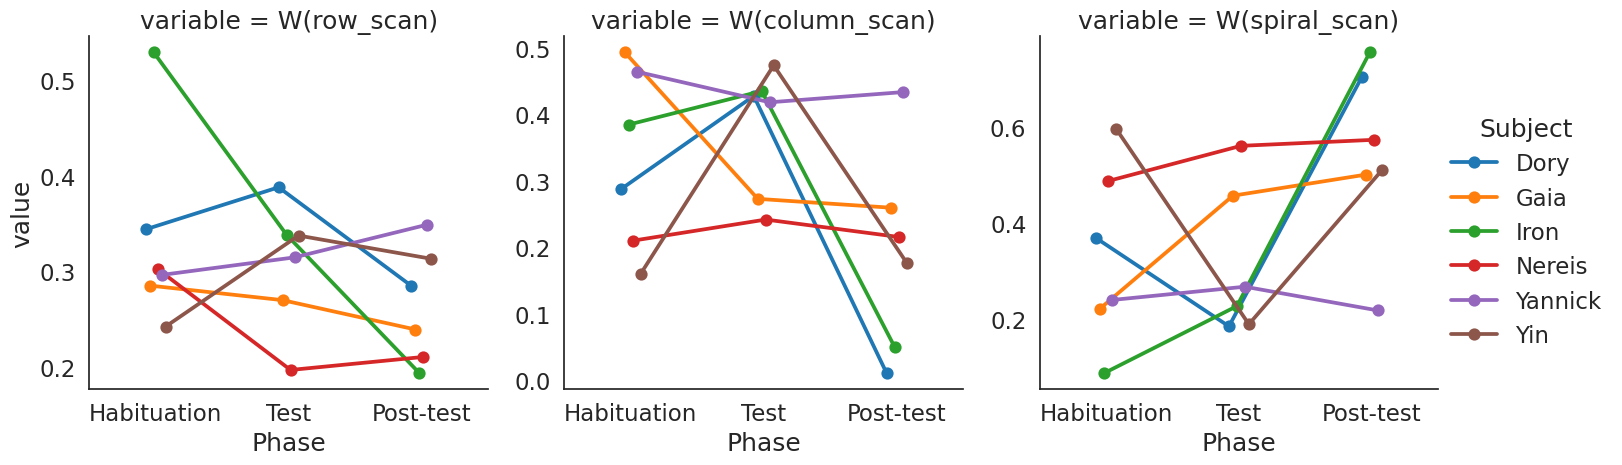

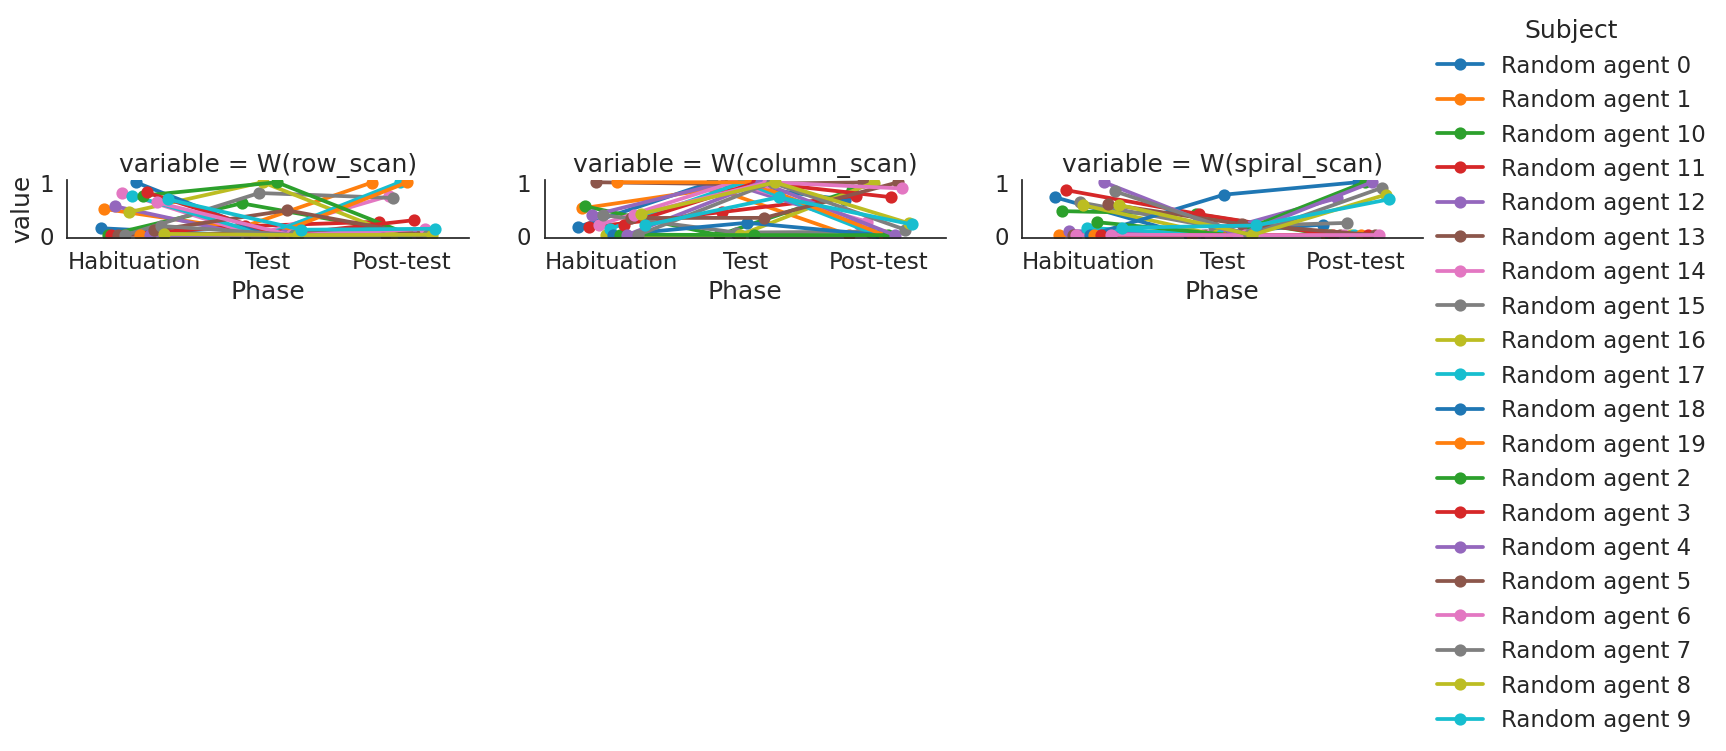

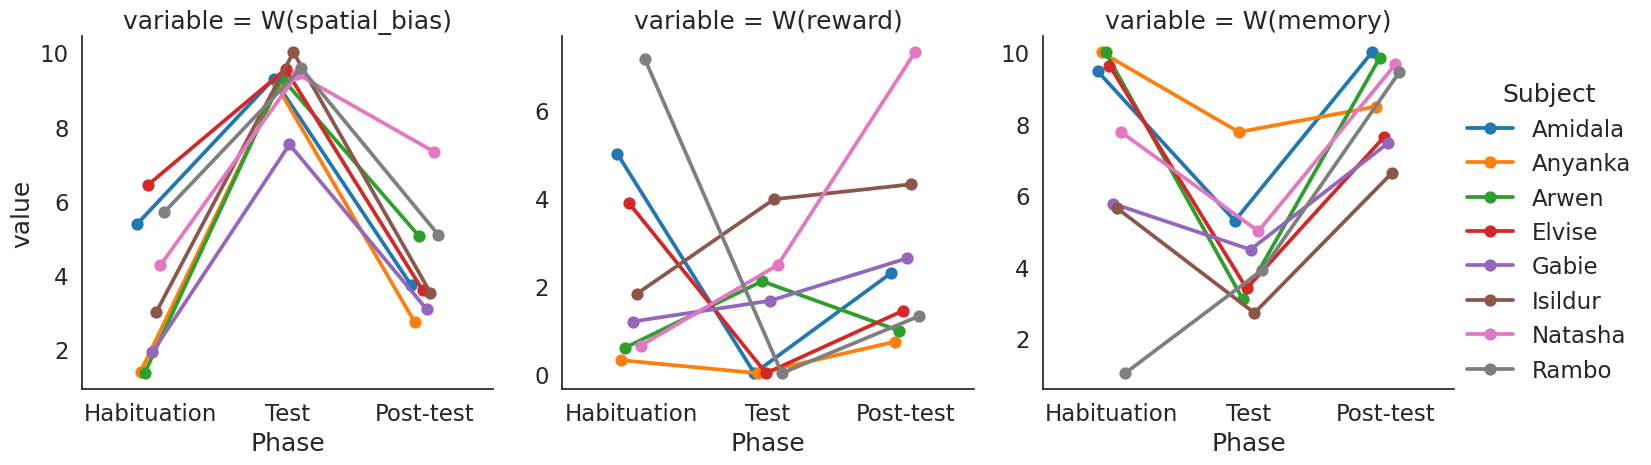

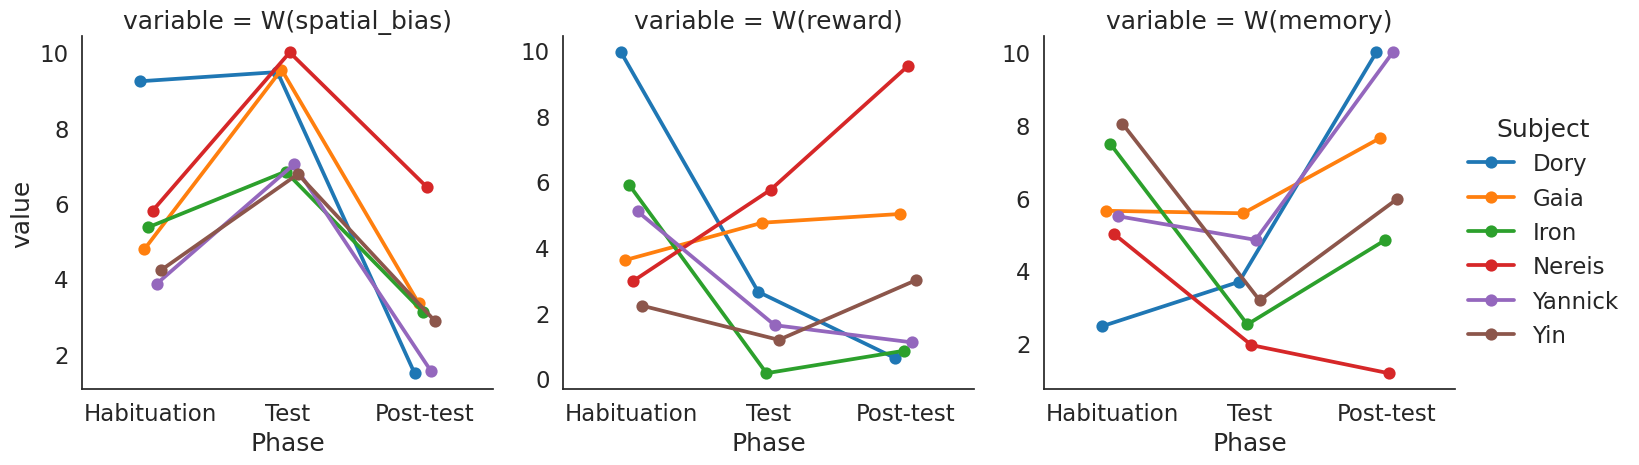

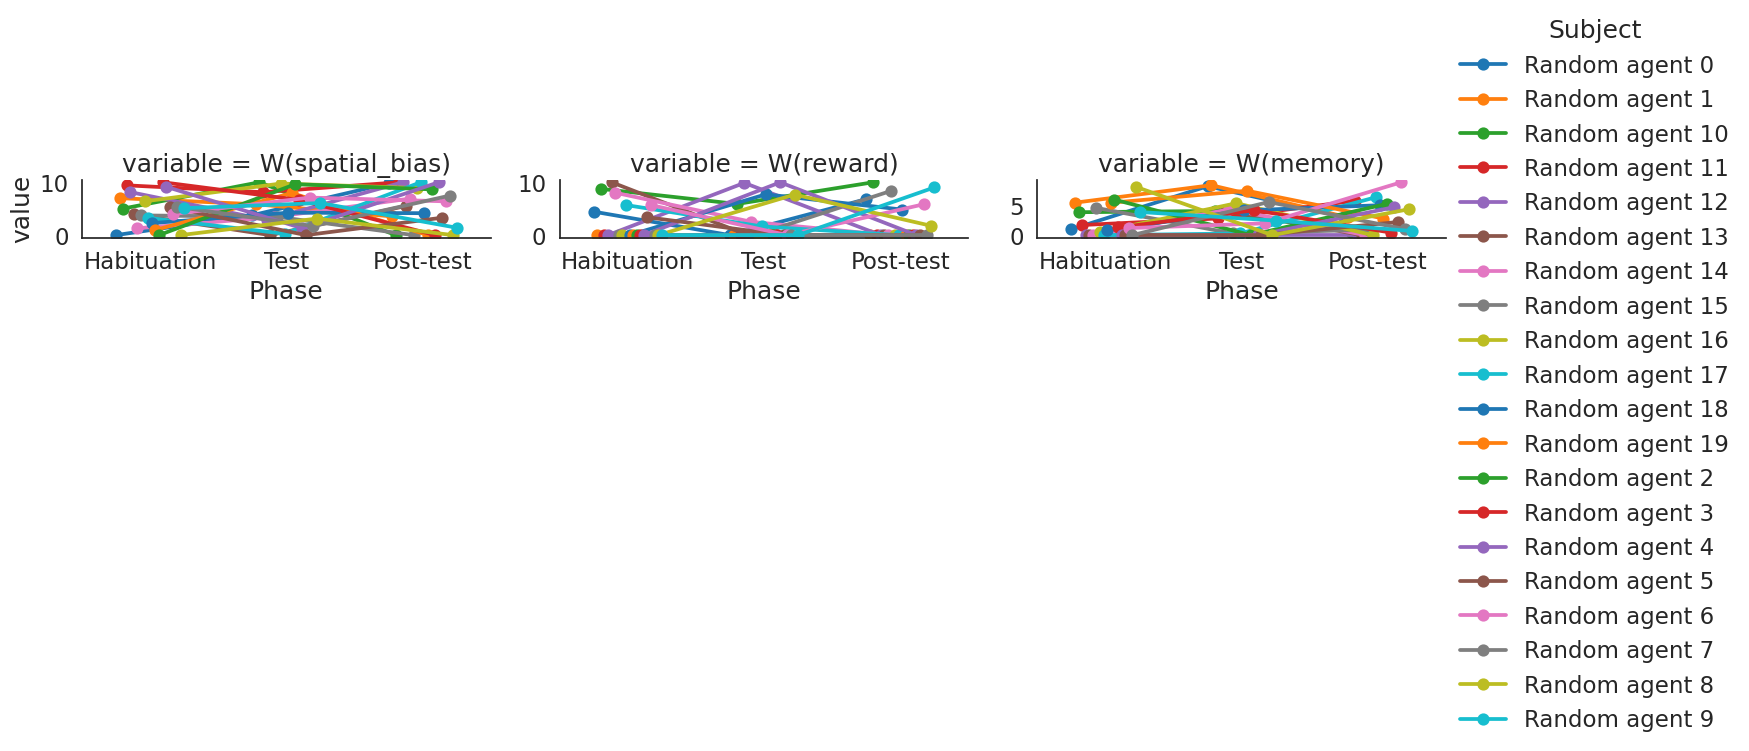

In [47]:
for grp in weights_spatial_df.groupby('Species'):
    print(grp[0])
    g1 = sns.catplot(x="Phase",y="value",col='variable',data=grp[1],kind='point',dodge=True,hue='Subject',col_wrap=3,sharey=False,palette='tab10',order=phase_order)
    g1.figure.savefig(fig_dir+"animal_wise_weights_spatial_"+grp[0]+".png")

for grp in weights_other_df.groupby('Species'):
    print(grp[0])
    g1 = sns.catplot(x="Phase",y="value",col='variable',data=grp[1],kind='point',dodge=True,hue='Subject',col_wrap=3,sharey=False,palette='tab10',order=phase_order)
    g1.figure.savefig(fig_dir+"animal_wise_weights_other_"+grp[0]+".png")        

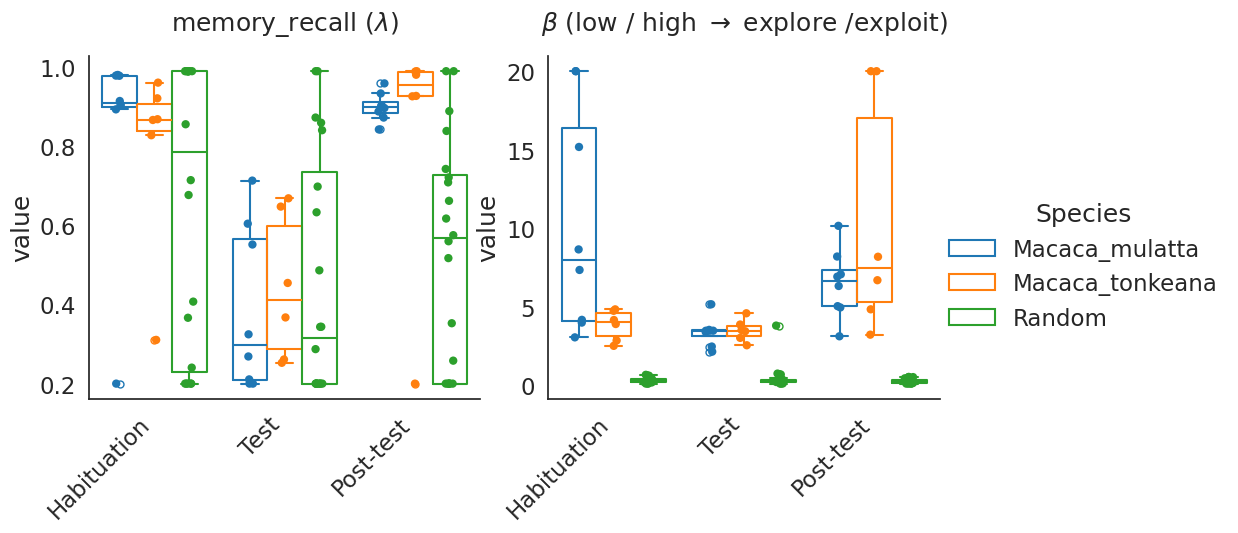

In [55]:
other_pars = to_plot.loc[~(to_plot['variable'].str.contains('W')|(to_plot['variable'].str.contains('nchoices')))]
g1_oth = plot_boxplots_with_points("Phase","value","variable",'Species',phase_order,cmap2,other_pars,2,True,False)
for ax in g1_oth.axes:
    tit = ax.get_title().split(' = ')[1]
    if tit == 'beta':
        tit = r'$\beta$'+' (low / high '+r'$\rightarrow$'+' explore /exploit)'
    ax.set_title(tit,y=1.05)
    ax.set_xlabel("")

g1_oth.savefig(fig_dir+"comparison_other_params_with_points_"+ps+".png")

Macaca_mulatta
Macaca_tonkeana
Random


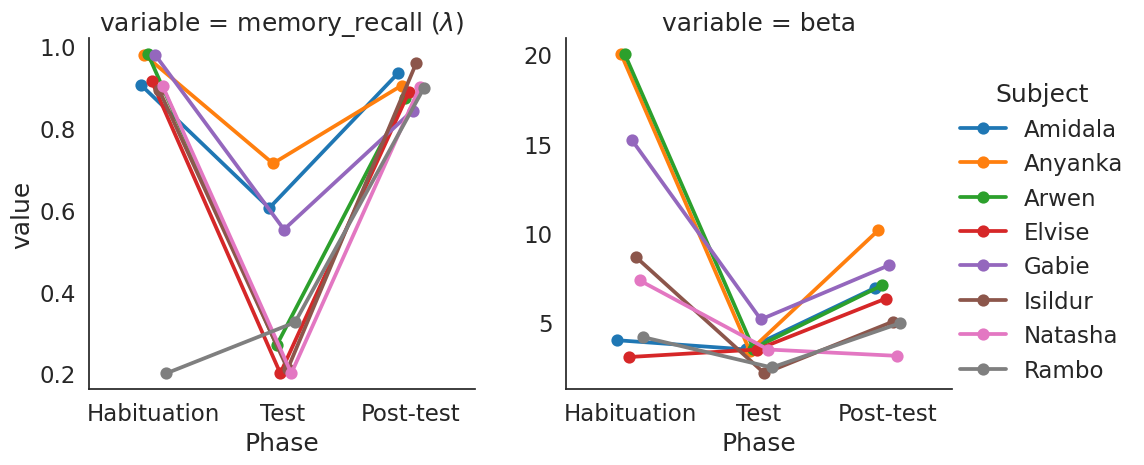

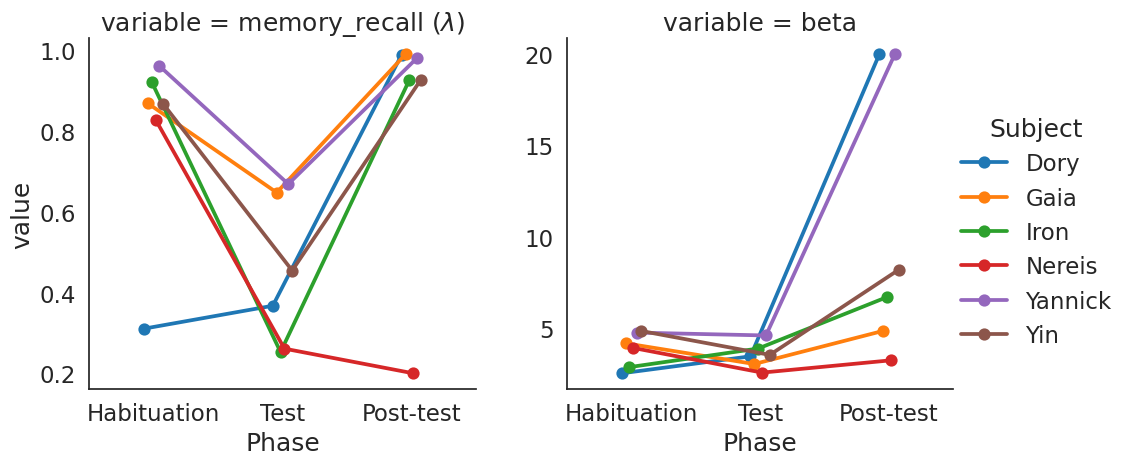

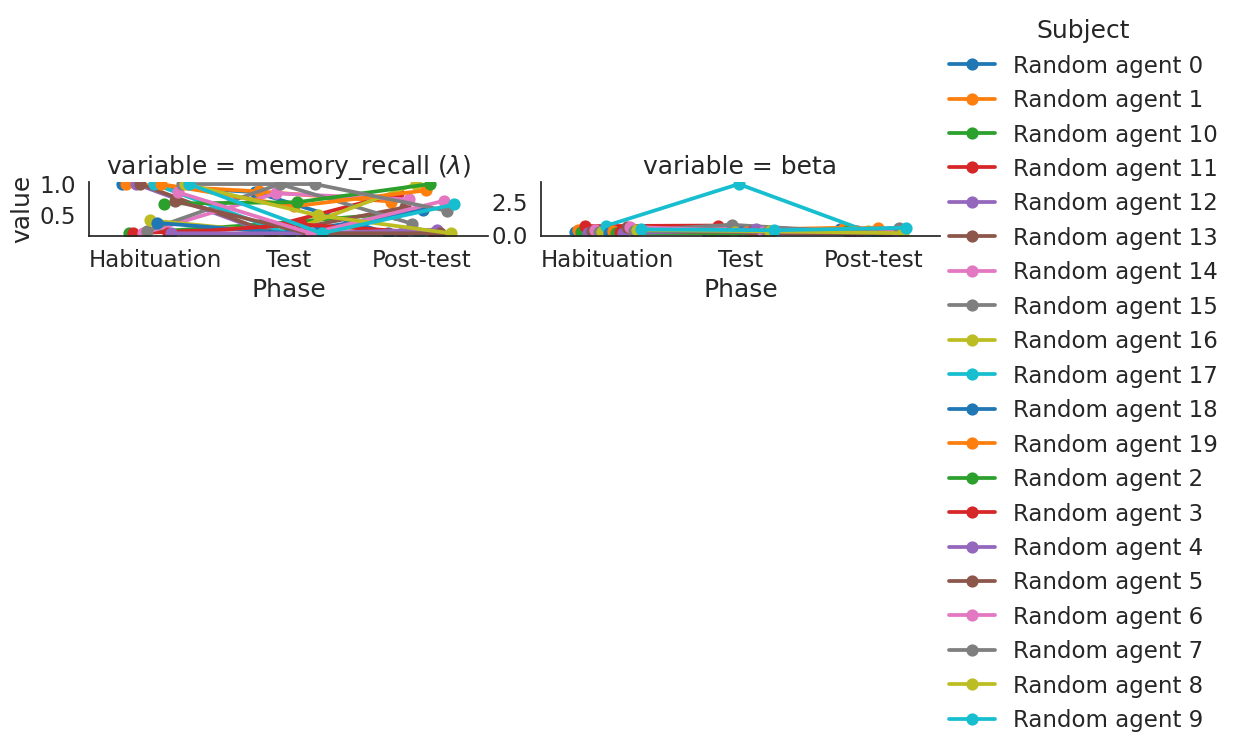

In [56]:
for grp in other_pars.groupby('Species'):
    print(grp[0])
    g1 = sns.catplot(x="Phase",y="value",col='variable',data=grp[1],kind='point',dodge=True,hue='Subject',col_wrap=2,sharey=False,palette='tab10',order=phase_order)
    g1.figure.savefig(fig_dir+"animal_wise_other_pars_"+grp[0]+".png")

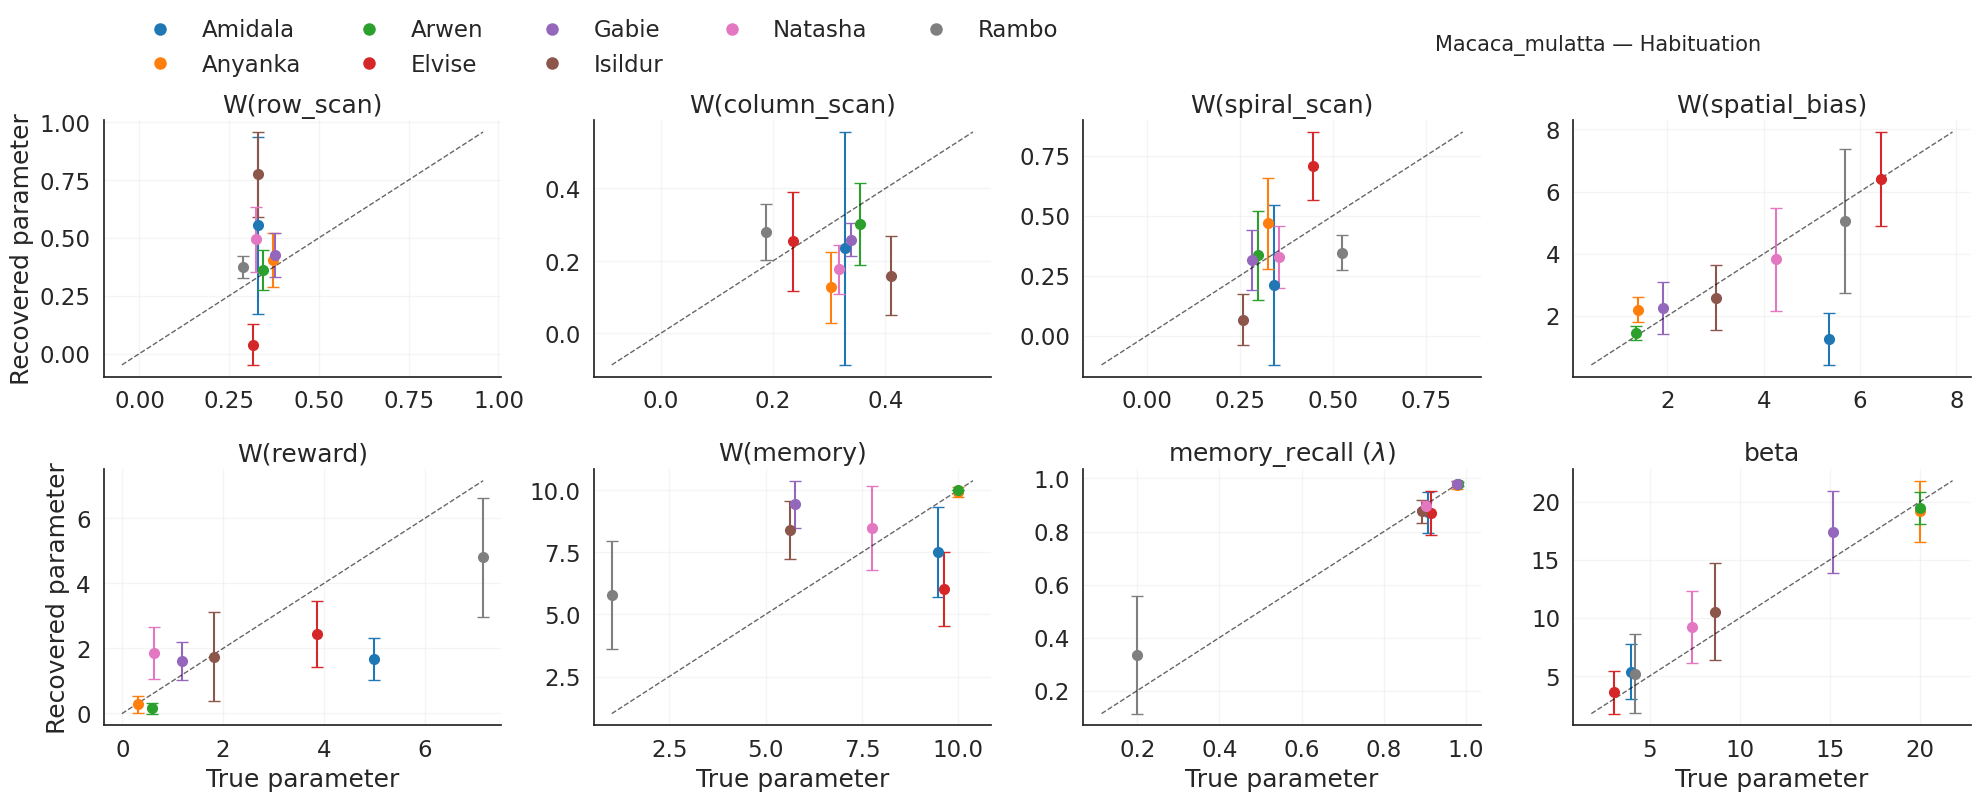

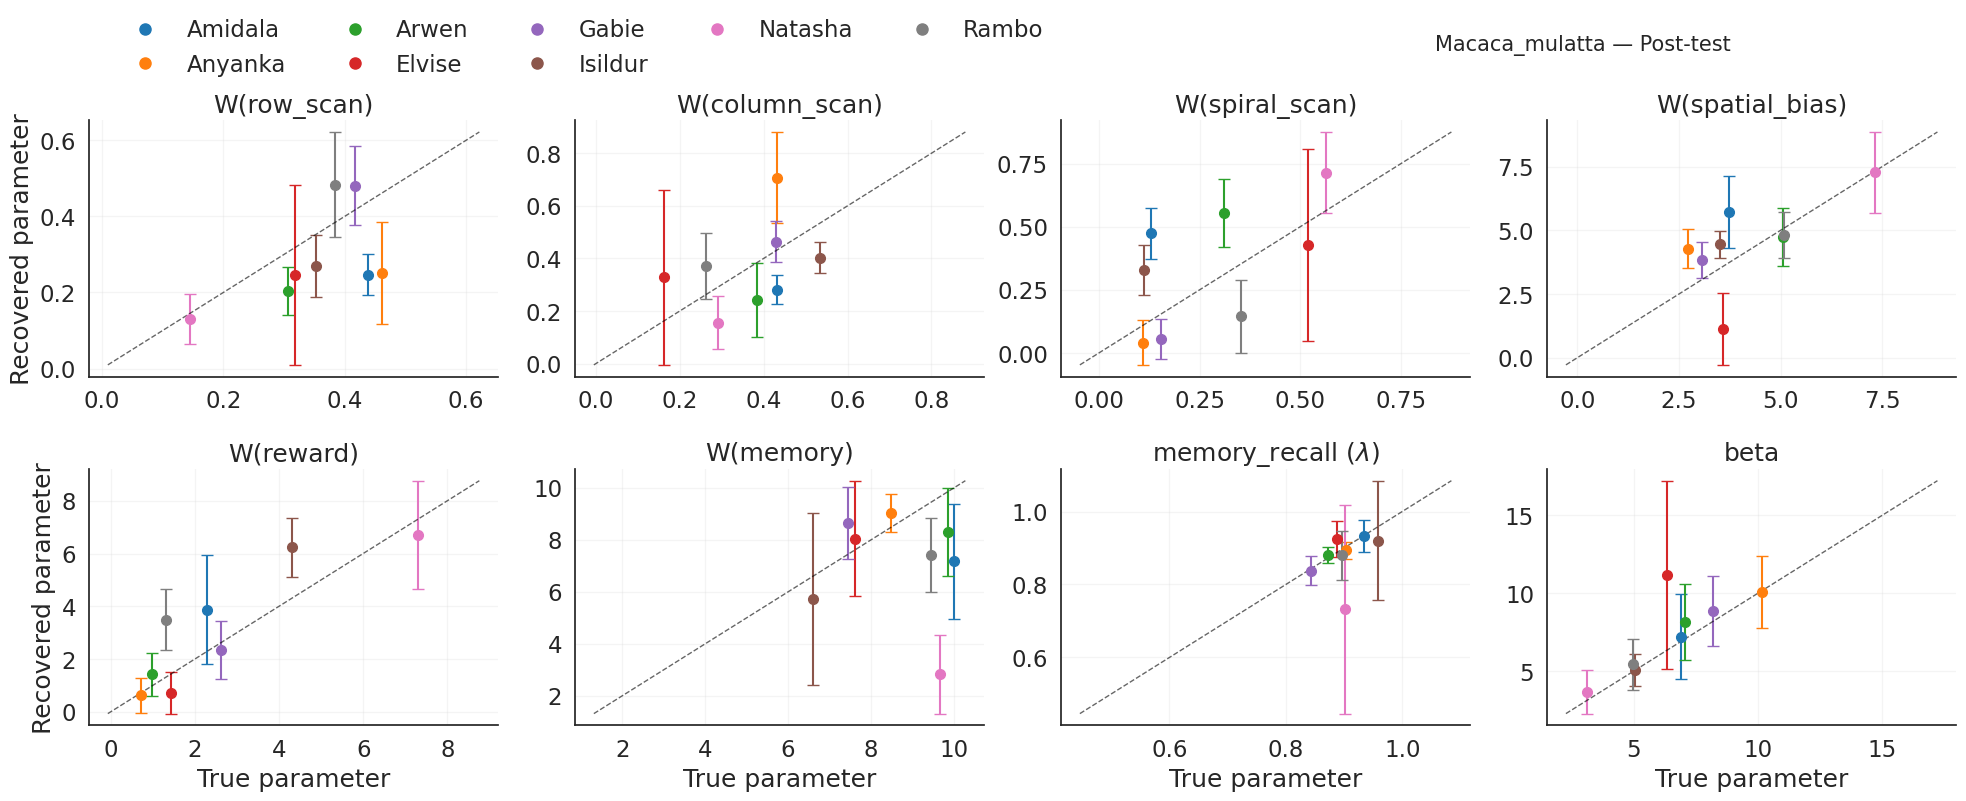

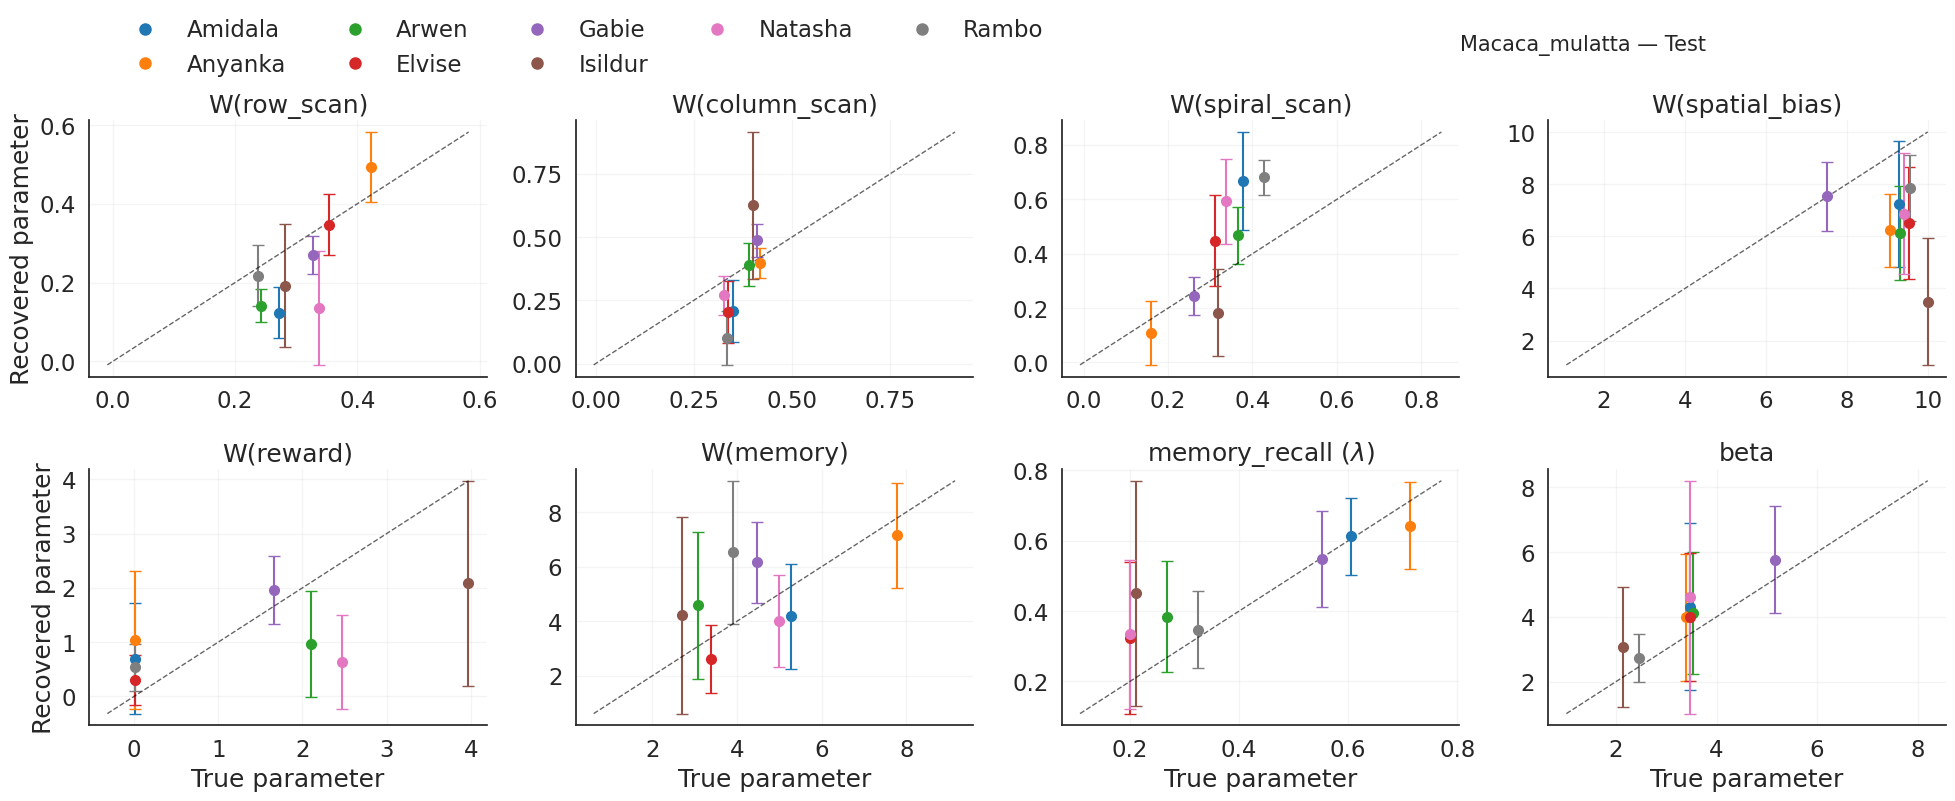

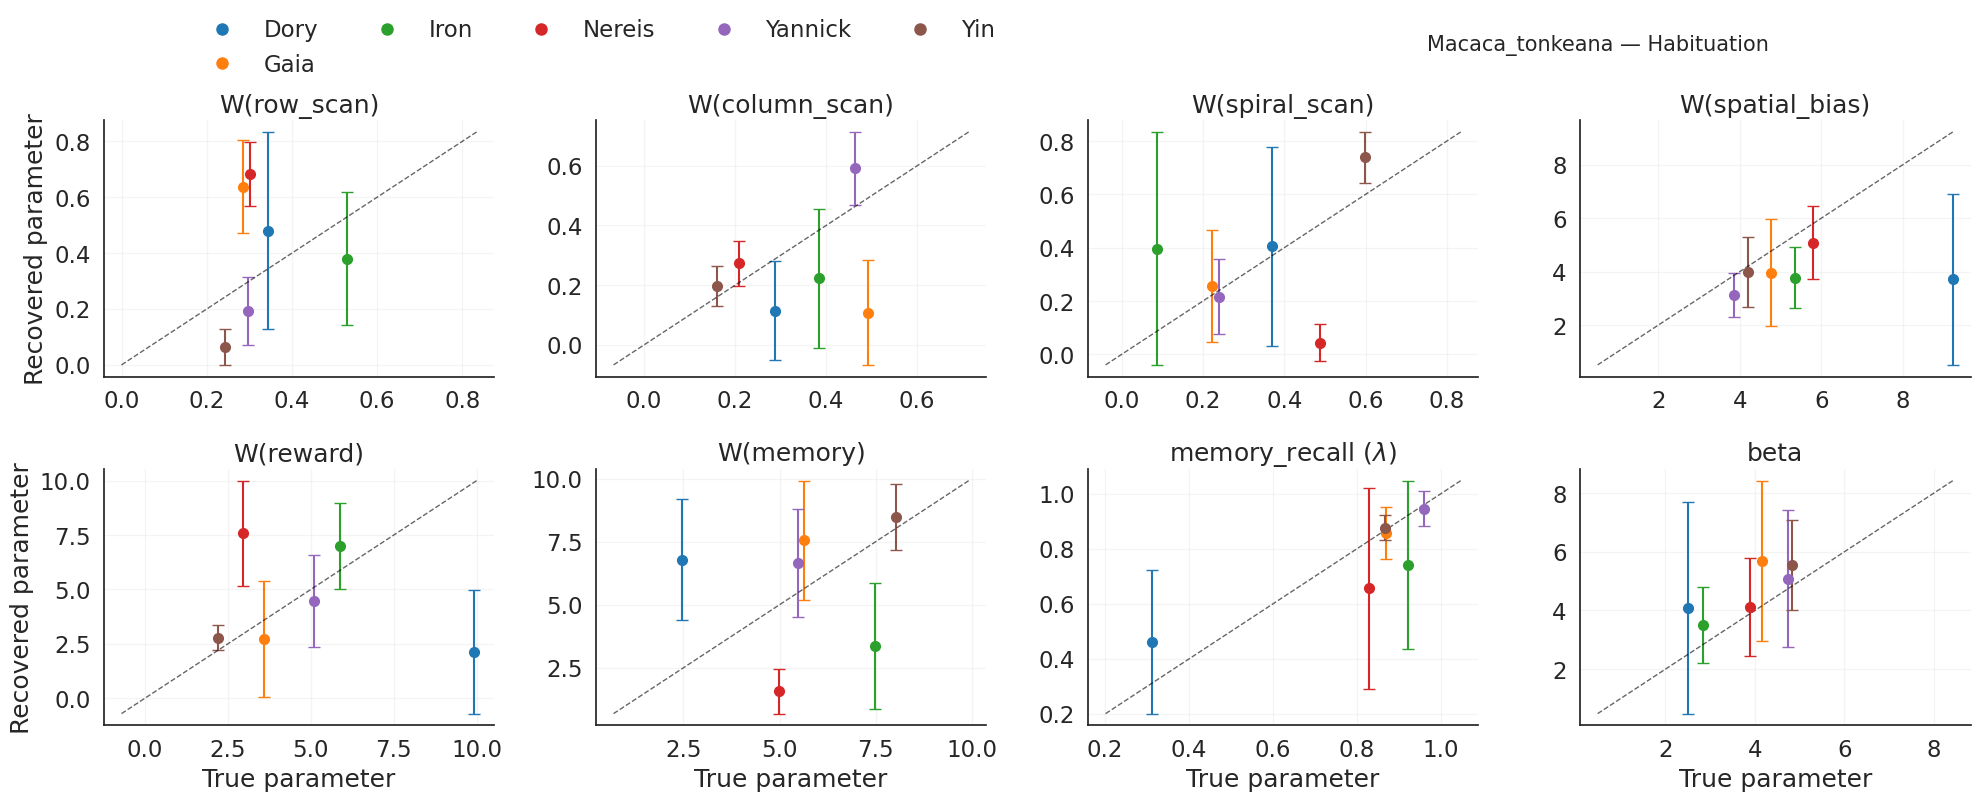

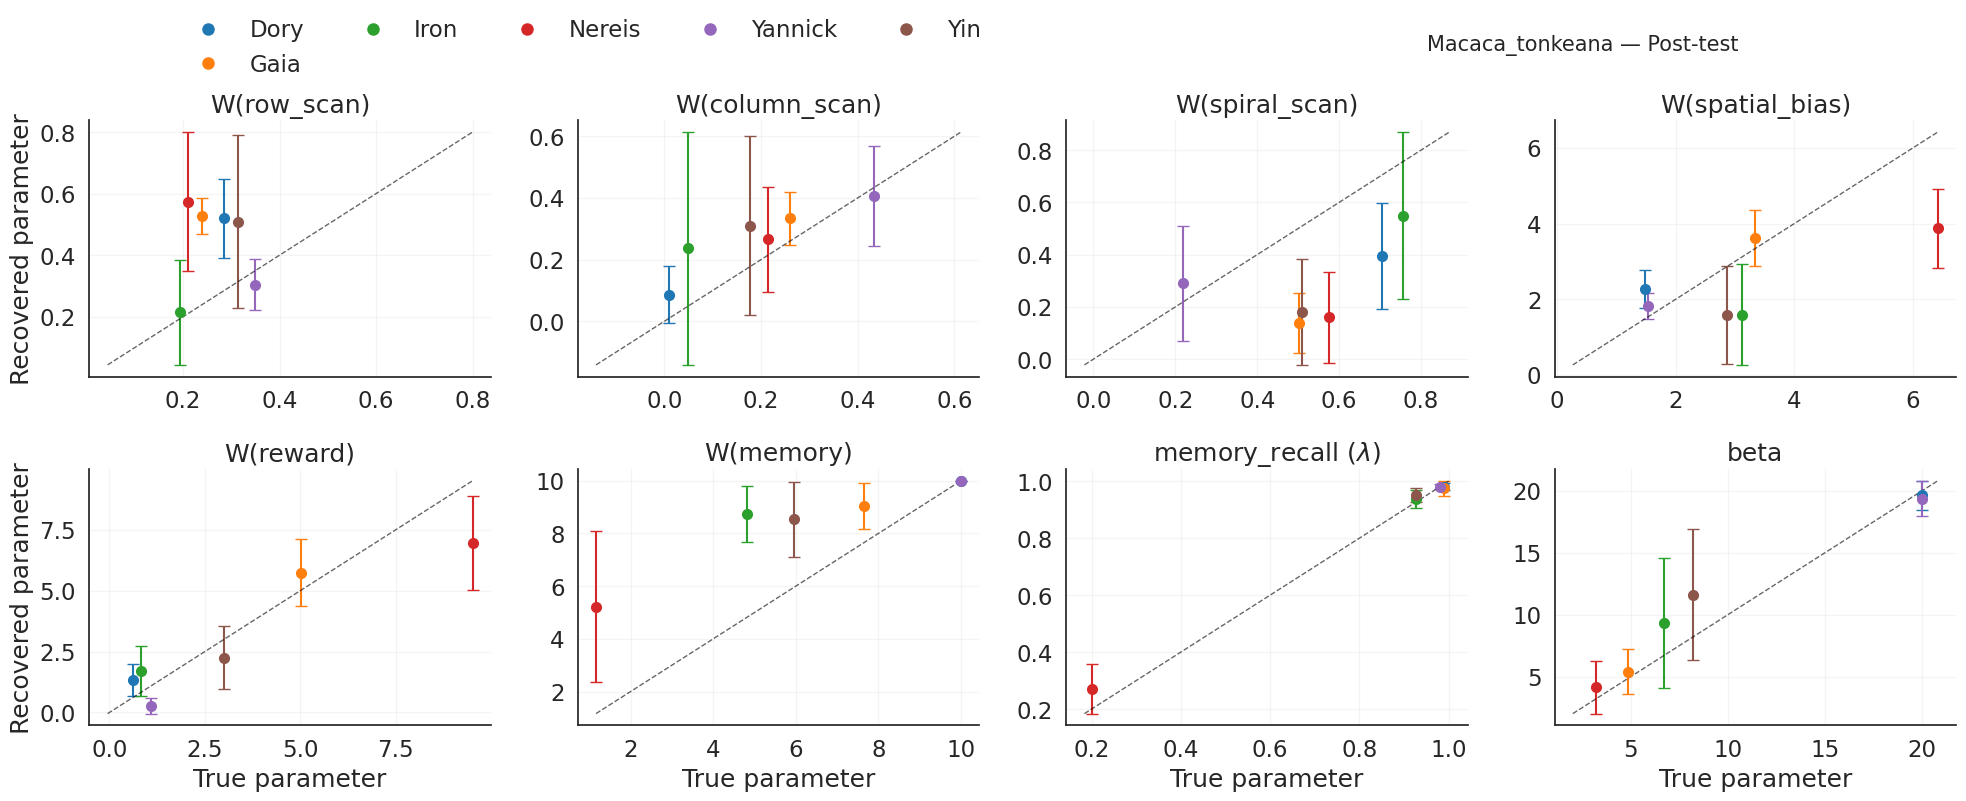

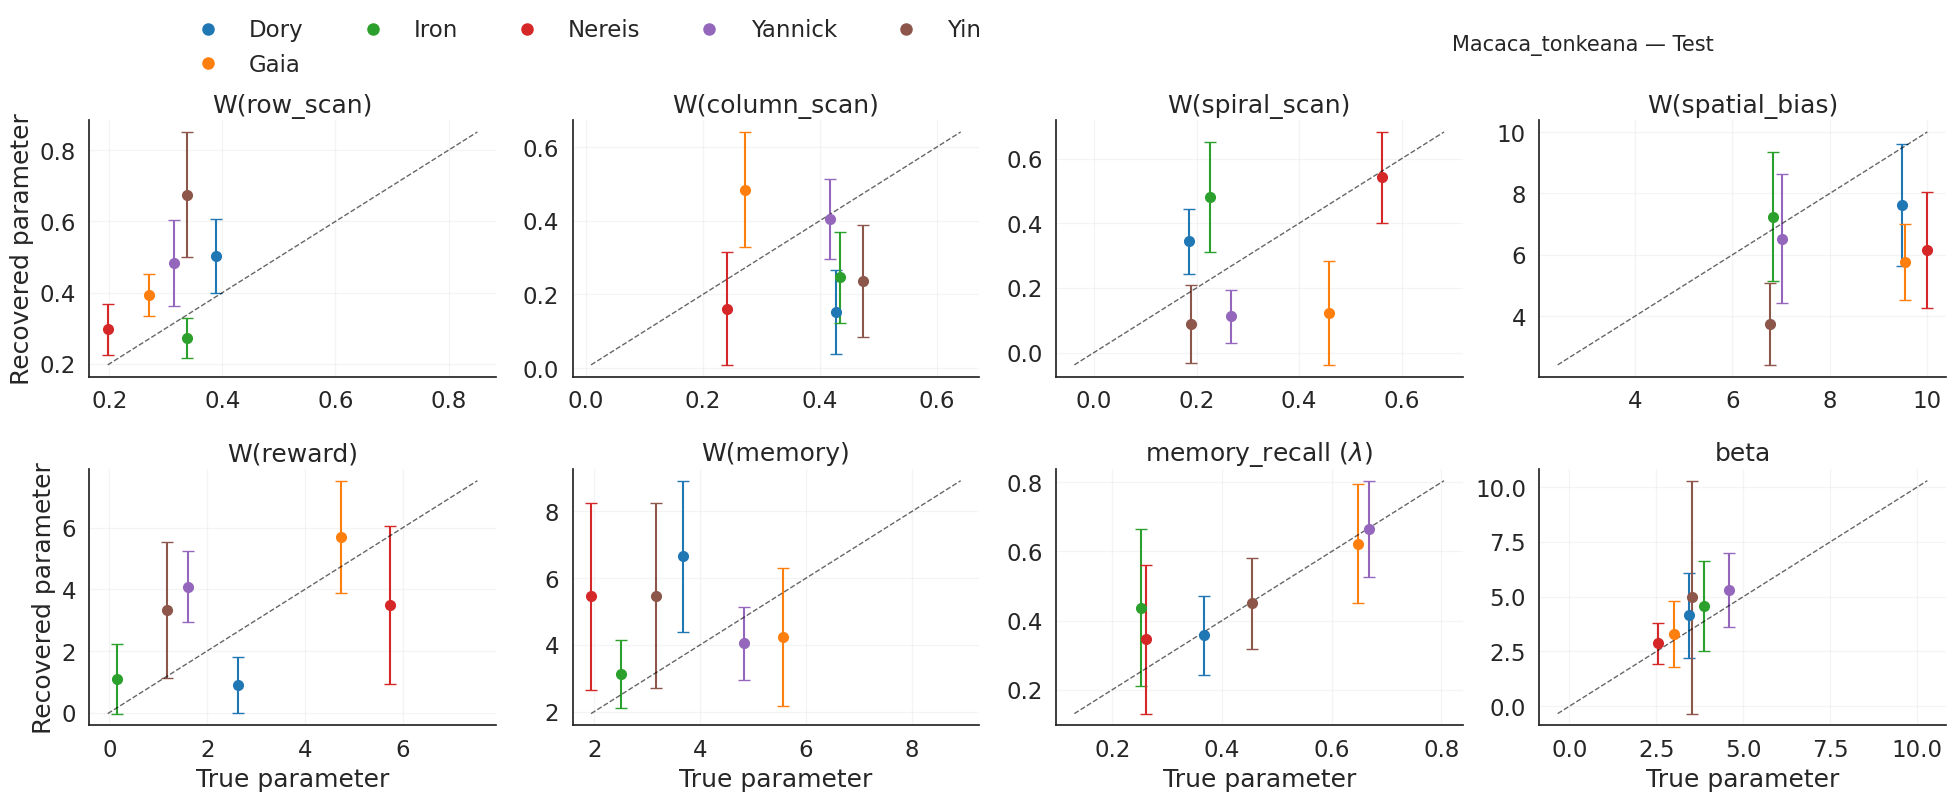

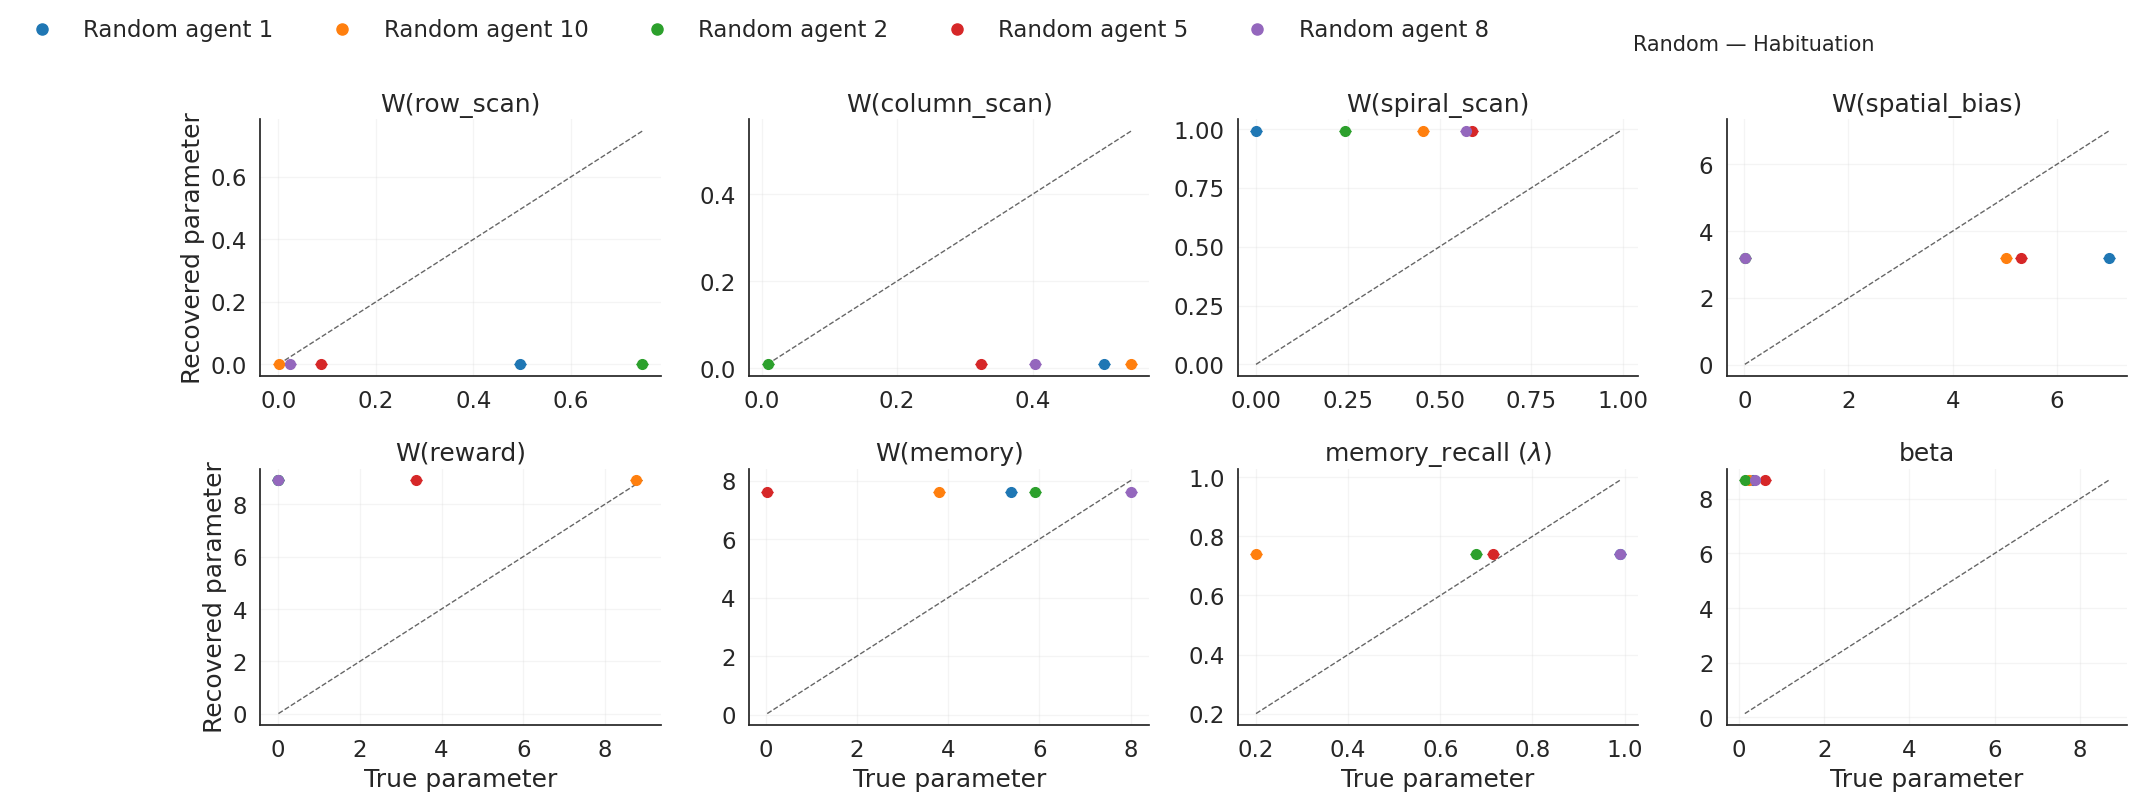

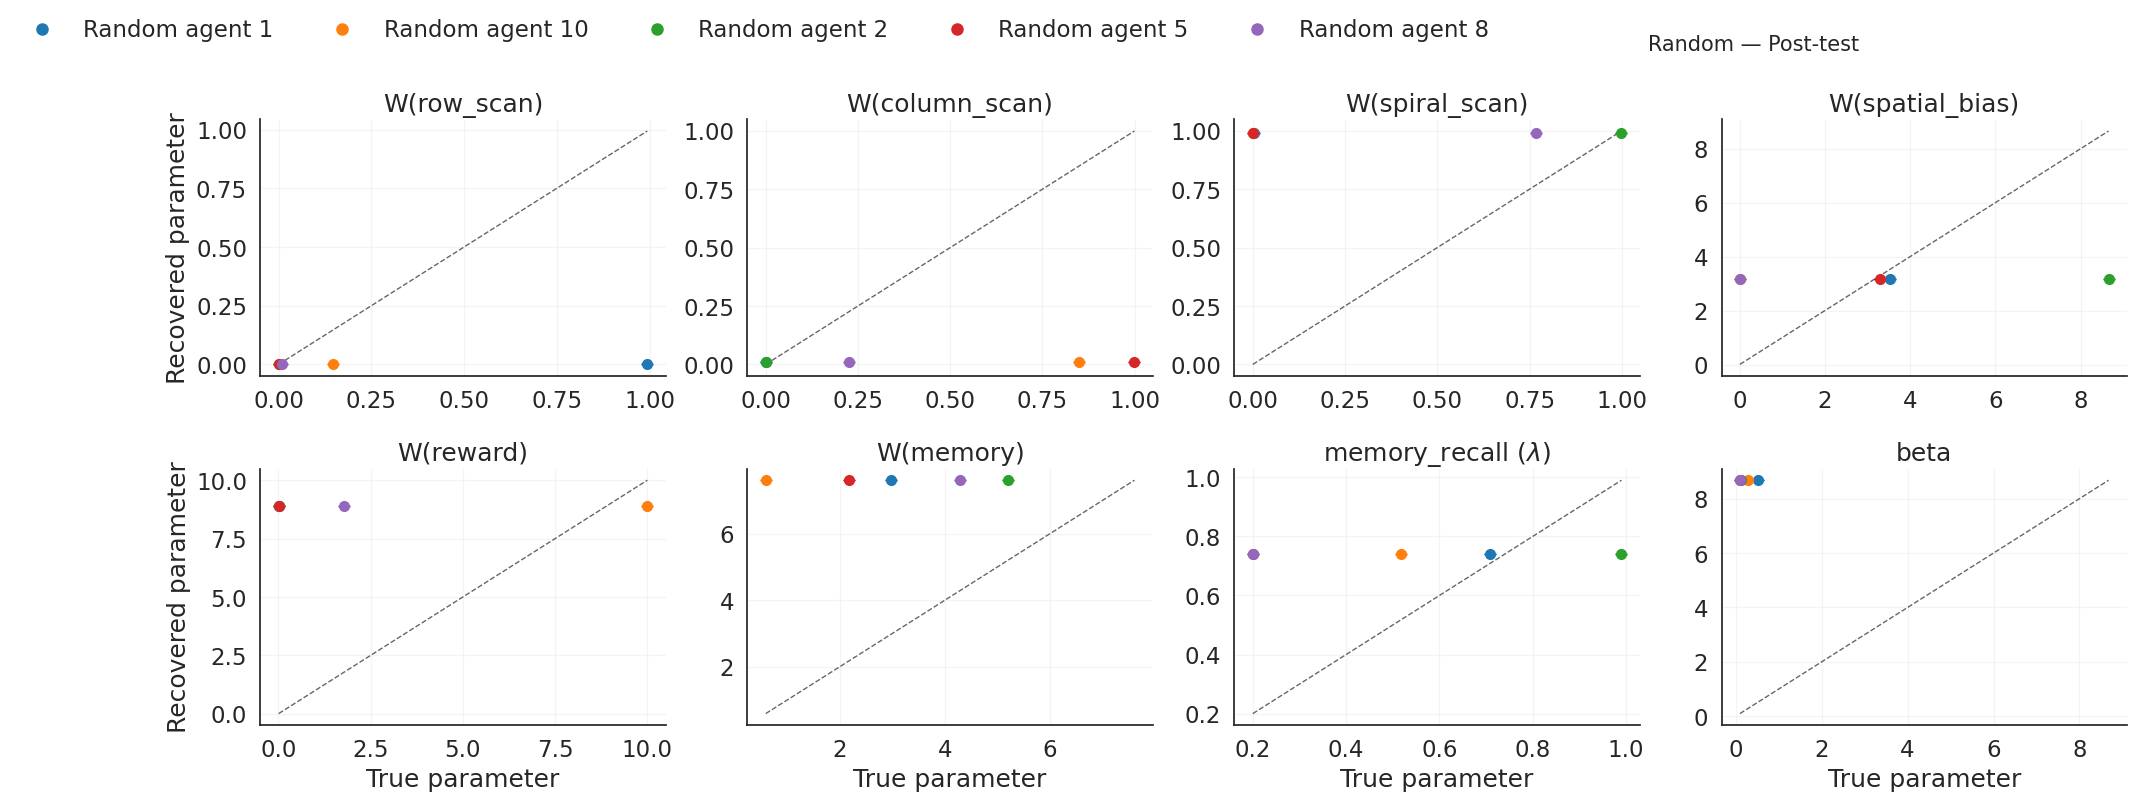

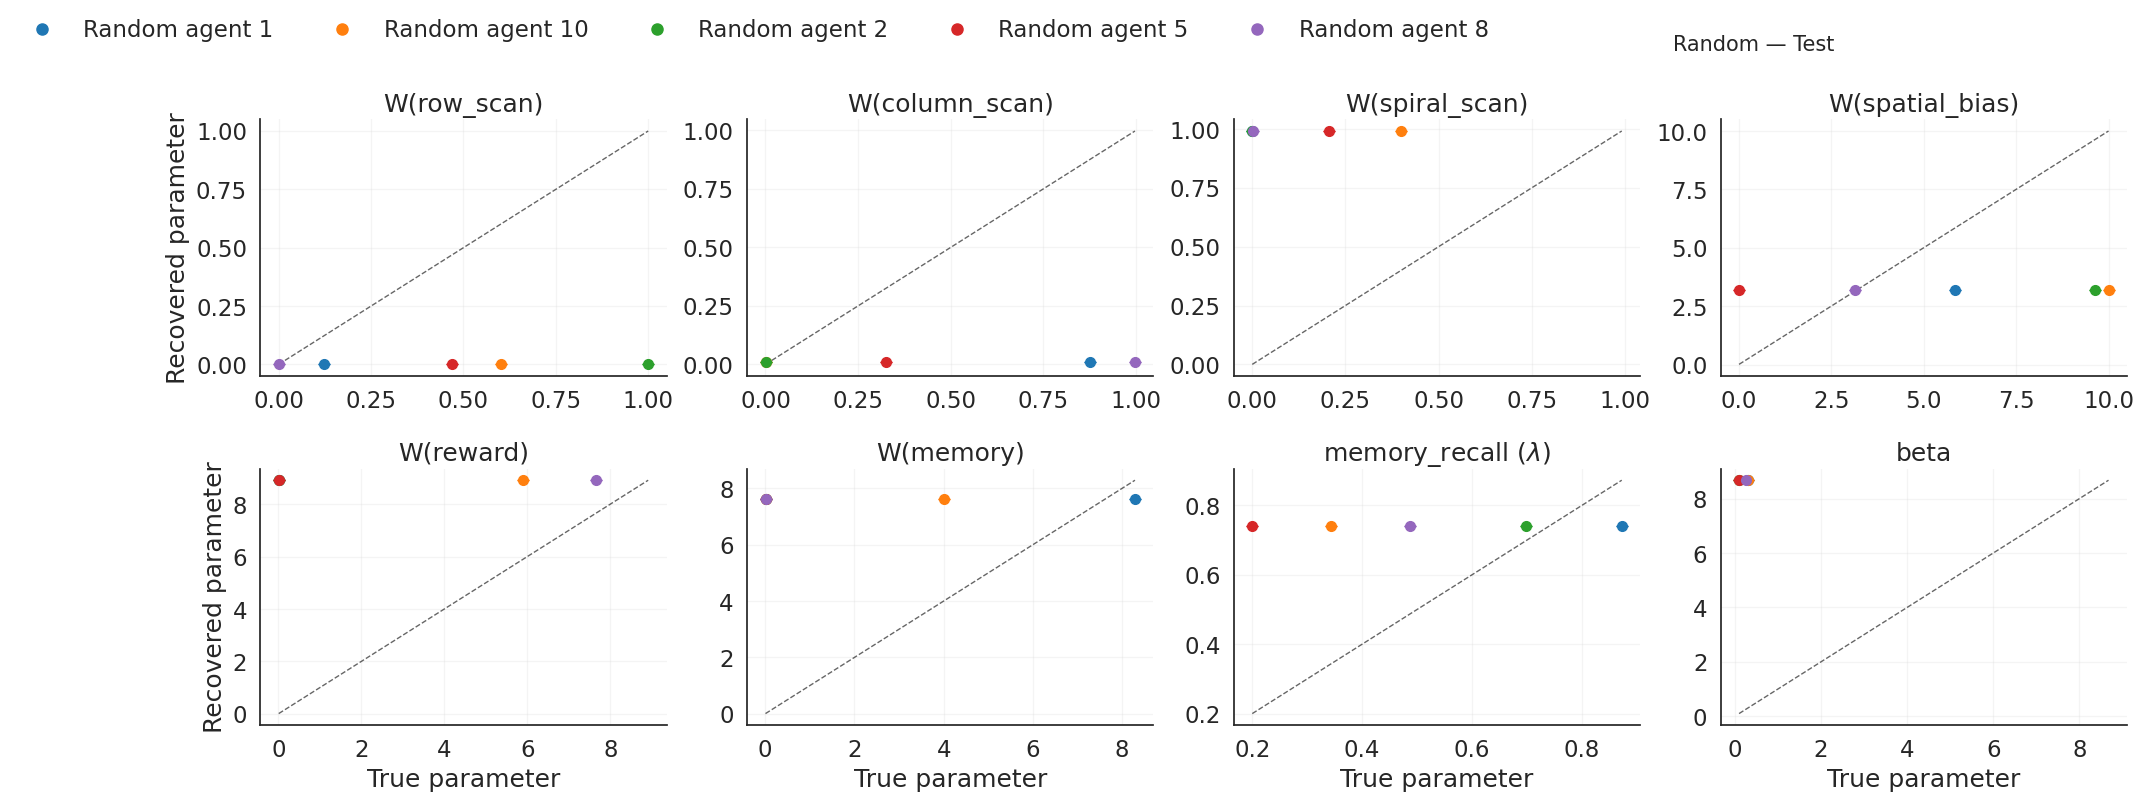

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

param_pairs = {
    "W(row_scan)": "W(row_scan) - sim",
    "W(column_scan)": "W(column_scan) - sim",
    "W(spiral_scan)": "W(spiral_scan) - sim",
    "W(spatial_bias)": "W(spatial_bias) - sim",
    "W(reward)": "W(reward) - sim",
    "W(memory)": "W(memory) - sim",
    "memory_recall ($\\lambda$)": "memory_recall ($\\lambda$) - sim",
    "beta": "beta - sim"
}


# ------------------------------------------------------------
# Copy dataframe
# ------------------------------------------------------------

df = recovery_df.copy()


# ------------------------------------------------------------
# Fill true parameter values down within each recovery group
# ------------------------------------------------------------

group_cols = ["Subject", "Phase", "Species"]

for true_col in param_pairs.keys():

    df[true_col] = (
        df.groupby(group_cols)[true_col]
          .transform("first")
    )


# ------------------------------------------------------------
# Keep only recovery rows
# ------------------------------------------------------------

sim_cols = list(param_pairs.values())

df_recovery = df[
    df[sim_cols[0]].notna()
].copy()


# ------------------------------------------------------------
# Loop over Species × Phase
# ------------------------------------------------------------

for (species, phase), df_group in df_recovery.groupby(
    ["Species", "Phase"]
):

    df_group = df_group.copy()

    # --------------------------------------------------------
    # Subjects in this Species × Phase
    # --------------------------------------------------------

    subjects = sorted(
        df_group["Subject"].dropna().unique()
    )

    # Same colors for subjects throughout this figure
    palette = sns.color_palette(
        "tab10",
        n_colors=len(subjects)
    )

    subject_colors = dict(
        zip(subjects, palette)
    )


    # --------------------------------------------------------
    # Figure layout
    # --------------------------------------------------------

    n_params = len(param_pairs)

    ncols = 4
    nrows = int(np.ceil(n_params / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(20, 4 * nrows)
    )

    axes = np.asarray(axes).flatten()


    # --------------------------------------------------------
    # One subplot per parameter
    # --------------------------------------------------------
    ax_i = 0
    for ax, (true_col, sim_col) in zip(
        axes,
        param_pairs.items()
    ):

        # ----------------------------------------------------
        # Mean ± SD for each Subject × true parameter
        # ----------------------------------------------------

        summary = (
            df_group
            .groupby(
                ["Subject", true_col]
            )[sim_col]
            .agg(
                mean="mean",
                std="std",
                n="count"
            )
            .reset_index()
        )


        # ----------------------------------------------------
        # Plot each subject
        # ----------------------------------------------------

        for subject in subjects:

            sub = summary[
                summary["Subject"] == subject
            ]

            if sub.empty:
                continue

            x = sub[true_col].values
            y = sub["mean"].values
            yerr = sub["std"].values

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                fmt="o",
                markersize=7,
                capsize=4,
                linewidth=1.5,
                color=subject_colors[subject],
                label=subject
            )


        # ----------------------------------------------------
        # Perfect recovery line
        # ----------------------------------------------------

        all_x = summary[true_col].values
        all_y = summary["mean"].values
        all_yerr = summary["std"].fillna(0).values

        if len(all_x) > 0:

            min_val = np.nanmin(
                np.concatenate([
                    all_x,
                    all_y - all_yerr
                ])
            )

            max_val = np.nanmax(
                np.concatenate([
                    all_x,
                    all_y + all_yerr
                ])
            )

            ax.plot(
                [min_val, max_val],
                [min_val, max_val],
                "--",
                color="black",
                alpha=0.6,
                linewidth=1
            )


        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_xlabel("True parameter")
        ax.set_ylabel("Recovered parameter")

        ax.set_title(true_col)

        ax.grid(alpha=0.2)

        if ax_i <=3 :
            ax.set_xlabel("")
        
        if ax_i not in [0,4]:
            ax.set_ylabel("")
            
        ax.spines.top.set_visible(False)
        ax.spines.right.set_visible(False)
        ax_i = ax_i + 1
    # --------------------------------------------------------
    # Hide unused axes
    # --------------------------------------------------------

    for ax in axes[n_params:]:
        ax.axis("off")


    # --------------------------------------------------------
    # Common legend
    # --------------------------------------------------------

    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            color=subject_colors[s],
            markersize=8,
            label=s
        )
        for s in subjects
    ]

    fig.legend(
        handles=handles,
        labels=subjects,
#         title="Subject",
        loc="upper center",
        bbox_to_anchor=(0.3, 1.025),
        ncol=min(len(subjects), 5),
        frameon=False
    )


    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------

    fig.suptitle(
        f"{species} — {phase}",
        fontsize=15,
        y=0.98,
        x = 0.8
    )
#     fig.subplots_adjust(top=0.7)
    plt.tight_layout()

    fig.savefig(fig_dir+"recovery_plots_"+species+"_"+phase+".png")